In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [6]:
def load_all_participants(averaged_dir='/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'):
    """
    Load all participant data from the averaged directory.
    
    Returns:
        Dictionary with 'intune' and 'outtune' keys, each containing participant DataFrames
    """
    averaged_path = Path(averaged_dir)
    participant_folders = [f for f in averaged_path.iterdir() if f.is_dir()]
    
    intune_dfs = {}
    outtune_dfs = {}
    
    for participant_folder in sorted(participant_folders):
        participant_name = participant_folder.name
        
        # Load in-tune data
        intune_file = participant_folder / f"{participant_name}_inavg.csv"
        if intune_file.exists():
            df = pd.read_csv(intune_file)
            intune_dfs[participant_name] = df
        
        # Load out-of-tune data
        outtune_file = participant_folder / f"{participant_name}_outavg.csv"
        if outtune_file.exists():
            df = pd.read_csv(outtune_file)
            outtune_dfs[participant_name] = df
    
    return {'intune': intune_dfs, 'outtune': outtune_dfs}

def compute_similarity_matrix(participant_dfs, condition='In'):
    """
    Compute cosine similarity matrix for participants.
    
    Args:
        participant_dfs: Dictionary of participant DataFrames
        condition: 'In' for in-tune, 'Out' for out-of-tune
    
    Returns:
        similarity_df: DataFrame containing similarity matrix
        rt_matrix: Raw RT matrix used for computation
        participant_names: List of participant names
    """
    rt_matrix = []
    participant_names = []
    
    for name, df in participant_dfs.items():
        # Find the RT column (should be like "participantInAveRT" or "participantOutAveRT")
        rt_col = [col for col in df.columns if 'AveRT' in col][0]
        rt_values = df[rt_col].values
        rt_matrix.append(rt_values)
        participant_names.append(name.capitalize())
    
    # Convert to numpy array
    rt_matrix = np.array(rt_matrix)
    
    # Compute cosine similarity
    similarity_matrix = cosine_similarity(rt_matrix)
    
    # Create a DataFrame for nicer display
    similarity_df = pd.DataFrame(similarity_matrix, 
                                 index=participant_names, 
                                 columns=participant_names)
    
    return similarity_df, rt_matrix, participant_names

def plot_similarity_heatmap(similarity_df, condition='In-Tune', output_file=None):
    """
    Plot a heatmap of the similarity matrix.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(similarity_df, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                center=0.5, vmin=0, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=ax)
    
    ax.set_title(f'Cosine Similarity Matrix: {condition} Average RTs', 
                 fontweight='normal', pad=15)
    ax.set_xlabel('Participant', fontweight='normal')
    ax.set_ylabel('Participant', fontweight='normal')
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, format='pdf', bbox_inches='tight')
        plt.savefig(output_file.replace('.pdf', '.png'), format='png', bbox_inches='tight')
    
    plt.show()

def plot_hierarchical_clustering(rt_matrix, participant_names, condition='In-Tune', output_file=None):
    """
    Plot hierarchical clustering dendrogram.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(rt_matrix, method='ward')
    
    # Create dendrogram
    dendrogram(linkage_matrix, labels=participant_names, ax=ax, 
               leaf_font_size=11, color_threshold=0.7*max(linkage_matrix[:,2]))
    
    ax.set_title(f'Hierarchical Clustering: {condition} Response Patterns', 
                 fontweight='normal', pad=15)
    ax.set_xlabel('Participant', fontweight='normal')
    ax.set_ylabel('Distance', fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, format='pdf', bbox_inches='tight')
        plt.savefig(output_file.replace('.pdf', '.png'), format='png', bbox_inches='tight')
    
    plt.show()

In [9]:
# Cell 2: Define helper functions (UPDATED)
def load_all_participants(averaged_dir='/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'):
    """
    Load all participant data from the averaged directory.
    
    Returns:
        Dictionary with 'intune' and 'outtune' keys, each containing participant DataFrames
    """
    averaged_path = Path(averaged_dir)
    participant_folders = [f for f in averaged_path.iterdir() if f.is_dir()]
    
    intune_dfs = {}
    outtune_dfs = {}
    
    for participant_folder in sorted(participant_folders):
        participant_name = participant_folder.name
        
        # Load in-tune data
        intune_file = participant_folder / f"{participant_name}_inavg.csv"
        if intune_file.exists():
            df = pd.read_csv(intune_file)
            intune_dfs[participant_name] = df
        
        # Load out-of-tune data
        outtune_file = participant_folder / f"{participant_name}_outavg.csv"
        if outtune_file.exists():
            df = pd.read_csv(outtune_file)
            outtune_dfs[participant_name] = df
    
    return {'intune': intune_dfs, 'outtune': outtune_dfs}

def compute_similarity_matrix(participant_dfs, condition='In'):
    """
    Compute cosine similarity matrix for participants.
    
    Args:
        participant_dfs: Dictionary of participant DataFrames
        condition: 'In' for in-tune, 'Out' for out-of-tune
    
    Returns:
        similarity_df: DataFrame containing similarity matrix
        rt_matrix: Raw RT matrix used for computation
        participant_names: List of participant names
    """
    # First, find all unique Gap values across all participants
    all_gaps = set()
    for name, df in participant_dfs.items():
        all_gaps.update(df['Gap'].values)
    
    # Sort gaps
    all_gaps = sorted(list(all_gaps))
    print(f"Found {len(all_gaps)} unique gap values: {min(all_gaps)} to {max(all_gaps)}")
    
    rt_matrix = []
    participant_names = []
    
    for name, df in participant_dfs.items():
        # Find the RT column
        rt_col = [col for col in df.columns if 'AveRT' in col][0]
        
        # Create a series indexed by Gap for easy alignment
        rt_series = df.set_index('Gap')[rt_col]
        
        # Align to all gaps, filling missing values with the mean of that participant
        aligned_rt = []
        for gap in all_gaps:
            if gap in rt_series.index:
                aligned_rt.append(rt_series[gap])
            else:
                # Fill missing gaps with participant's mean RT
                aligned_rt.append(rt_series.mean())
        
        rt_matrix.append(aligned_rt)
        participant_names.append(name.capitalize())
        
        # Report missing gaps
        missing_gaps = set(all_gaps) - set(df['Gap'].values)
        if missing_gaps:
            print(f"  {name}: Missing {len(missing_gaps)} gaps, filled with mean ({rt_series.mean():.2f})")
    
    # Convert to numpy array
    rt_matrix = np.array(rt_matrix)
    print(f"\nRT matrix shape: {rt_matrix.shape}")
    
    # Compute cosine similarity
    similarity_matrix = cosine_similarity(rt_matrix)
    
    # Create a DataFrame for nicer display
    similarity_df = pd.DataFrame(similarity_matrix, 
                                 index=participant_names, 
                                 columns=participant_names)
    
    return similarity_df, rt_matrix, participant_names

def plot_similarity_heatmap(similarity_df, condition='In-Tune', output_file=None):
    """
    Plot a heatmap of the similarity matrix.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(similarity_df, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                center=0.5, vmin=0, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=ax)
    
    ax.set_title(f'Cosine Similarity Matrix: {condition} Average RTs', 
                 fontweight='normal', pad=15)
    ax.set_xlabel('Participant', fontweight='normal')
    ax.set_ylabel('Participant', fontweight='normal')
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, format='pdf', bbox_inches='tight')
        plt.savefig(output_file.replace('.pdf', '.png'), format='png', bbox_inches='tight')
    
    plt.show()

def plot_hierarchical_clustering(rt_matrix, participant_names, condition='In-Tune', output_file=None):
    """
    Plot hierarchical clustering dendrogram.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(rt_matrix, method='ward')
    
    # Create dendrogram
    dendrogram(linkage_matrix, labels=participant_names, ax=ax, 
               leaf_font_size=11, color_threshold=0.7*max(linkage_matrix[:,2]))
    
    ax.set_title(f'Hierarchical Clustering: {condition} Response Patterns', 
                 fontweight='normal', pad=15)
    ax.set_xlabel('Participant', fontweight='normal')
    ax.set_ylabel('Distance', fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, format='pdf', bbox_inches='tight')
        plt.savefig(output_file.replace('.pdf', '.png'), format='png', bbox_inches='tight')
    
    plt.show()

In [10]:
print("Loading participant data...")
all_data = load_all_participants()

print(f"Found {len(all_data['intune'])} participants with in-tune data")
print(f"Found {len(all_data['outtune'])} participants with out-of-tune data")
print("\nParticipants:", list(all_data['intune'].keys()))

Loading participant data...
Found 9 participants with in-tune data
Found 9 participants with out-of-tune data

Participants: ['addie', 'angelyn', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree']


In [11]:
# Cell 4: In-Tune Analysis
print("="*60)
print("IN-TUNE ANALYSIS")
print("="*60)

similarity_in, rt_matrix_in, names_in = compute_similarity_matrix(
    all_data['intune'], condition='In'
)

print("\nCosine Similarity Matrix (In-Tune Average RTs):")
display(similarity_in.round(4))

IN-TUNE ANALYSIS
Found 46 unique gap values: 50 to 500
  addie: Missing 2 gaps, filled with mean (516.61)
  jill: Missing 2 gaps, filled with mean (677.07)
  manaswini: Missing 17 gaps, filled with mean (900.99)
  navya: Missing 2 gaps, filled with mean (596.40)

RT matrix shape: (9, 46)

Cosine Similarity Matrix (In-Tune Average RTs):


,Addie,Angelyn,Jill,Lila,Mahalakshmi,Manaswini,Navya,Richard,Sree
Addie,1.0000,0.9761,0.9796,0.9775,0.9772,0.9842,0.9755,0.9791,0.9793
Angelyn,0.9761,1.0000,0.9915,0.9909,0.9886,0.9919,0.9822,0.9868,0.9876
Jill,0.9796,0.9915,1.0000,0.9877,0.9875,0.9954,0.9860,0.9877,0.9876
Lila,0.9775,0.9909,0.9877,1.0000,0.9855,0.9914,0.9835,0.9876,0.9853
Mahalakshmi,0.9772,0.9886,0.9875,0.9855,1.0000,0.9907,0.9755,0.9845,0.9863
Manaswini,0.9842,0.9919,0.9954,0.9914,0.9907,1.0000,0.9874,0.9914,0.9939
Navya,0.9755,0.9822,0.9860,0.9835,0.9755,0.9874,1.0000,0.9804,0.9795
Richard,0.9791,0.9868,0.9877,0.9876,0.9845,0.9914,0.9804,1.0000,0.9889
Sree,0.9793,0.9876,0.9876,0.9853,0.9863,0.9939,0.9795,0.9889,1.0000


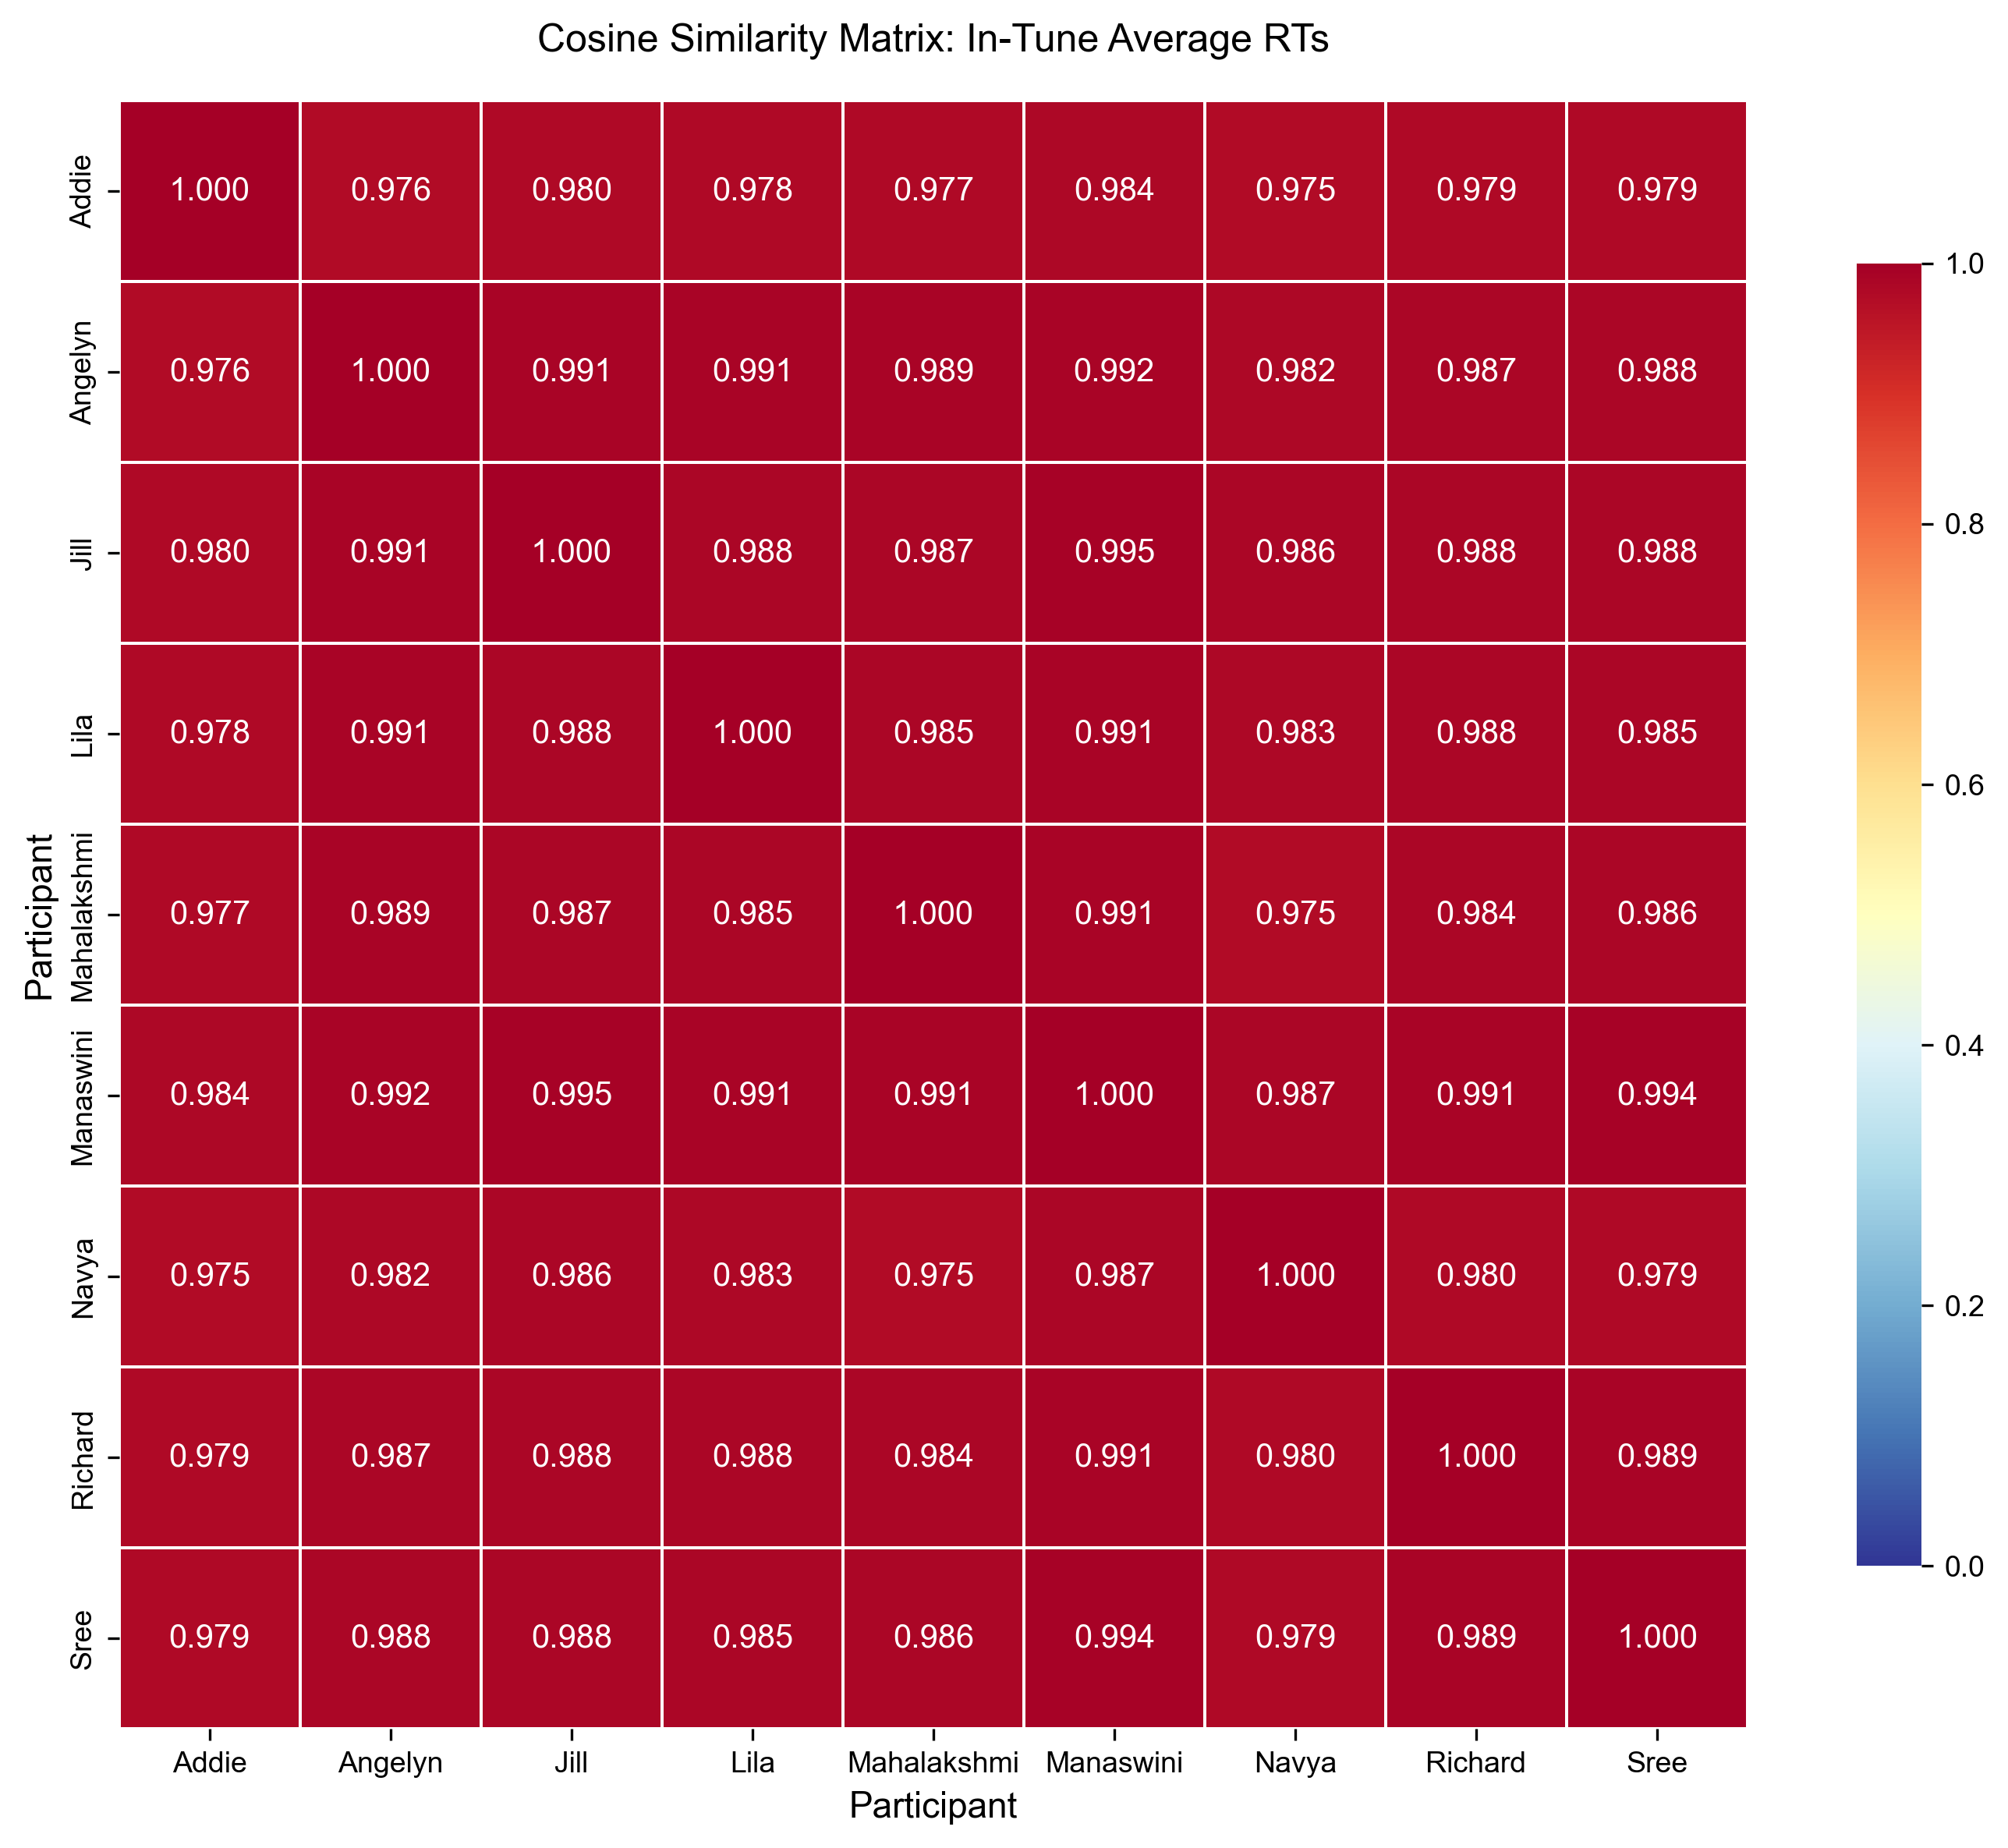

In [ ]:
plot_similarity_heatmap(similarity_in, condition='In-Tune', 
                       output_file='similarity_intune.pdf')

In [14]:
print("="*60)
print("OUT-OF-TUNE ANALYSIS")
print("="*60)

similarity_out, rt_matrix_out, names_out = compute_similarity_matrix(
    all_data['outtune'], condition='Out'
)

print("\nCosine Similarity Matrix (Out-of-Tune Average RTs):")
display(similarity_out.round(4))

OUT-OF-TUNE ANALYSIS
Found 46 unique gap values: 50 to 500
  addie: Missing 1 gaps, filled with mean (540.91)
  jill: Missing 13 gaps, filled with mean (715.06)
  lila: Missing 1 gaps, filled with mean (472.07)
  manaswini: Missing 17 gaps, filled with mean (879.86)
  navya: Missing 6 gaps, filled with mean (624.55)
  richard: Missing 1 gaps, filled with mean (560.09)

RT matrix shape: (9, 46)

Cosine Similarity Matrix (Out-of-Tune Average RTs):


,Addie,Angelyn,Jill,Lila,Mahalakshmi,Manaswini,Navya,Richard,Sree
Addie,1.0000,0.9770,0.9780,0.9746,0.9779,0.9812,0.9726,0.9763,0.9794
Angelyn,0.9770,1.0000,0.9945,0.9845,0.9849,0.9941,0.9895,0.9904,0.9887
Jill,0.9780,0.9945,1.0000,0.9879,0.9860,0.9957,0.9862,0.9931,0.9912
Lila,0.9746,0.9845,0.9879,1.0000,0.9841,0.9908,0.9796,0.9885,0.9846
Mahalakshmi,0.9779,0.9849,0.9860,0.9841,1.0000,0.9892,0.9823,0.9867,0.9861
Manaswini,0.9812,0.9941,0.9957,0.9908,0.9892,1.0000,0.9868,0.9933,0.9929
Navya,0.9726,0.9895,0.9862,0.9796,0.9823,0.9868,1.0000,0.9817,0.9826
Richard,0.9763,0.9904,0.9931,0.9885,0.9867,0.9933,0.9817,1.0000,0.9898
Sree,0.9794,0.9887,0.9912,0.9846,0.9861,0.9929,0.9826,0.9898,1.0000


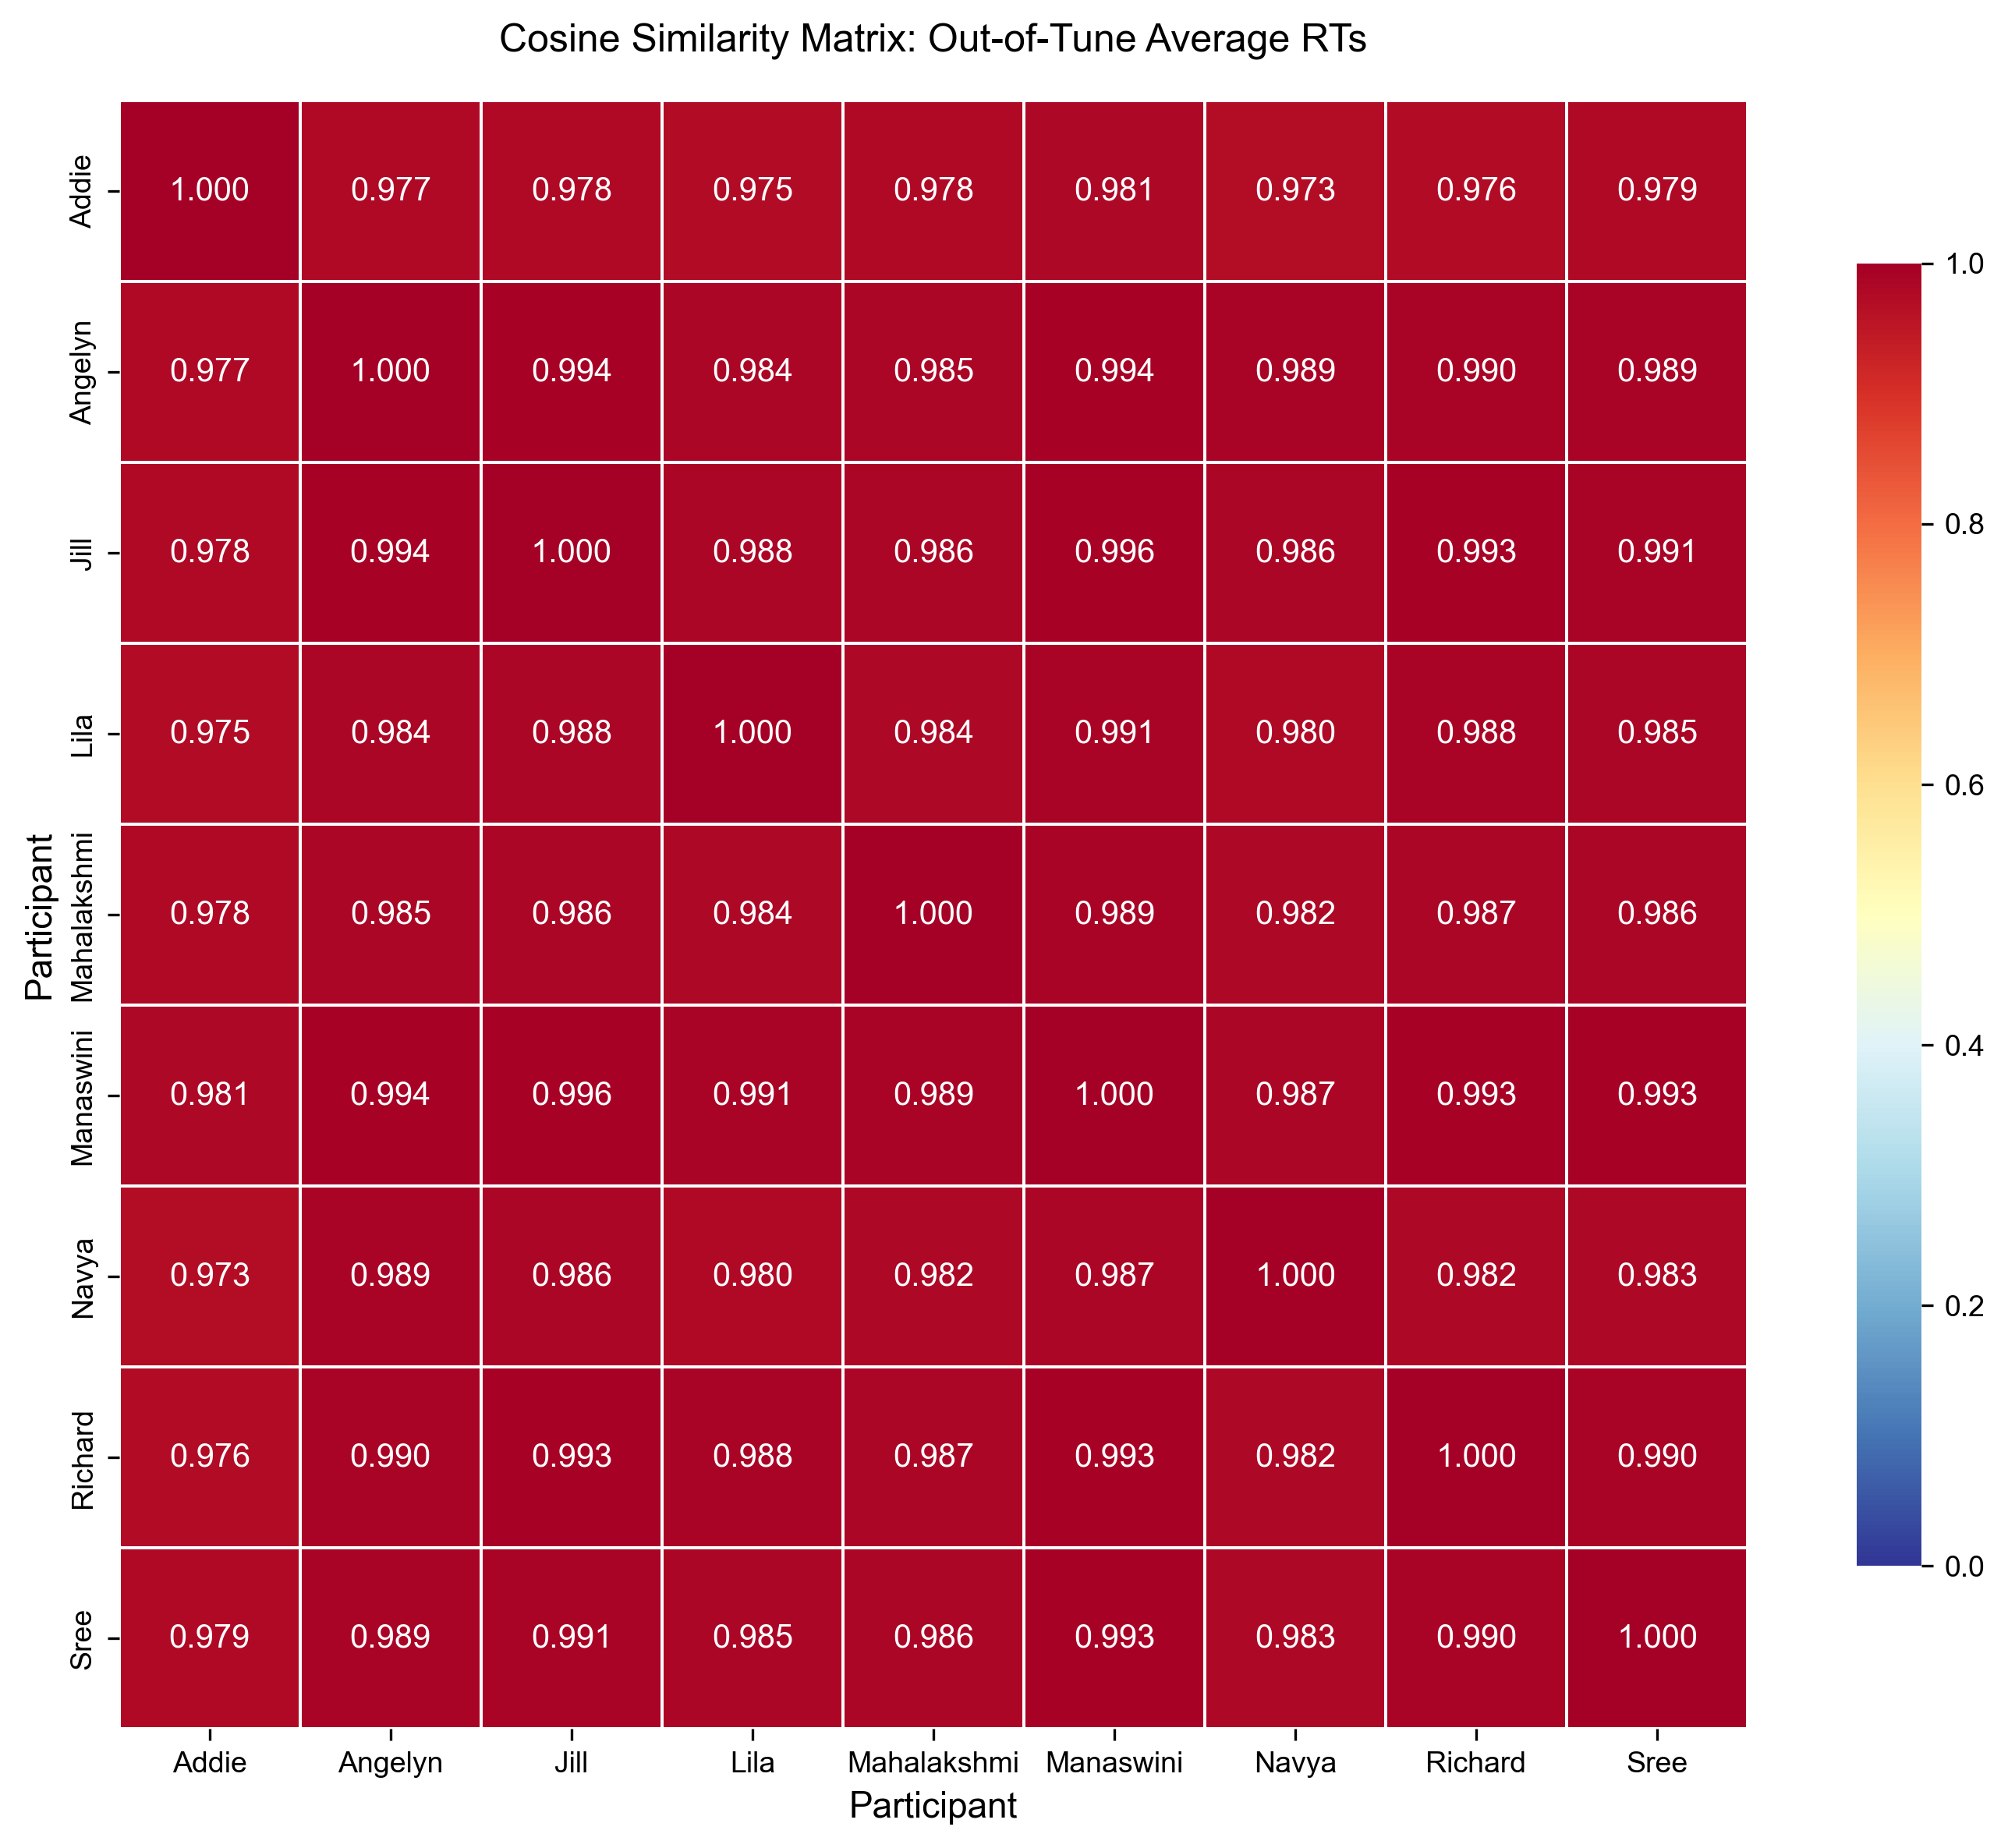

In [ ]:
plot_similarity_heatmap(similarity_out, condition='Out-of-Tune',
                       output_file='similarity_outtune.pdf')

In [18]:
print("="*60)
print("IN-TUNE AND OUT-OF-TUNE COMBINED (SEPARATE ROWS)")
print("="*60)

def compute_separate_condition_similarity(intune_dfs, outtune_dfs):
    """
    Compute cosine similarity matrix with separate rows for in-tune and out-of-tune.
    Each participant gets two rows: one for in-tune, one for out-of-tune.
    
    Returns:
        similarity_df: DataFrame with similarity matrix
        rt_matrix: RT matrix used
        participant_labels: List of labels (e.g., "AngelynI", "AngelynO")
    """
    # Find all unique Gap values
    all_gaps = set()
    for name, df in intune_dfs.items():
        all_gaps.update(df['Gap'].values)
    for name, df in outtune_dfs.items():
        all_gaps.update(df['Gap'].values)
    
    all_gaps = sorted(list(all_gaps))
    print(f"Found {len(all_gaps)} unique gap values: {min(all_gaps)} to {max(all_gaps)}\n")
    
    rt_matrix = []
    participant_labels = []
    
    # Get common participants
    common_participants = sorted(set(intune_dfs.keys()) & set(outtune_dfs.keys()))
    print(f"Analyzing {len(common_participants)} participants\n")
    
    for name in common_participants:
        intune_df = intune_dfs[name]
        outtune_df = outtune_dfs[name]
        
        # Find RT columns
        intune_rt_col = [col for col in intune_df.columns if 'AveRT' in col][0]
        outtune_rt_col = [col for col in outtune_df.columns if 'AveRT' in col][0]
        
        # Create series indexed by Gap
        intune_series = intune_df.set_index('Gap')[intune_rt_col]
        outtune_series = outtune_df.set_index('Gap')[outtune_rt_col]
        
        # Align in-tune values
        intune_aligned = []
        for gap in all_gaps:
            if gap in intune_series.index:
                intune_aligned.append(intune_series[gap])
            else:
                intune_aligned.append(intune_series.mean())
        
        # Align out-of-tune values
        outtune_aligned = []
        for gap in all_gaps:
            if gap in outtune_series.index:
                outtune_aligned.append(outtune_series[gap])
            else:
                outtune_aligned.append(outtune_series.mean())
        
        # Add both as separate rows
        rt_matrix.append(intune_aligned)
        participant_labels.append(f"{name.capitalize()}I")
        
        rt_matrix.append(outtune_aligned)
        participant_labels.append(f"{name.capitalize()}O")
    
    # Convert to numpy array
    rt_matrix = np.array(rt_matrix)
    print(f"RT matrix shape: {rt_matrix.shape}")
    print(f"Total rows (participants × conditions): {rt_matrix.shape[0]}")
    print(f"Features per row (gap values): {rt_matrix.shape[1]}\n")
    
    # Compute cosine similarity
    similarity_matrix = cosine_similarity(rt_matrix)
    
    # Create DataFrame
    similarity_df = pd.DataFrame(similarity_matrix, 
                                 index=participant_labels, 
                                 columns=participant_labels)
    
    return similarity_df, rt_matrix, participant_labels

# Compute the similarity matrix
similarity_separate, rt_matrix_separate, labels_separate = compute_separate_condition_similarity(
    all_data['intune'], all_data['outtune']
)

print("Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):")
display(similarity_separate.round(4))

IN-TUNE AND OUT-OF-TUNE COMBINED (SEPARATE ROWS)
Found 46 unique gap values: 50 to 500

Analyzing 9 participants

RT matrix shape: (18, 46)
Total rows (participants × conditions): 18
Features per row (gap values): 46

Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):


,AddieI,AddieO,AngelynI,AngelynO,JillI,JillO,LilaI,LilaO,MahalakshmiI,MahalakshmiO,ManaswiniI,ManaswiniO,NavyaI,NavyaO,RichardI,RichardO,SreeI,SreeO
AddieI,1.0000,0.9690,0.9761,0.9867,0.9796,0.9862,0.9775,0.9788,0.9772,0.9761,0.9842,0.9842,0.9755,0.9781,0.9791,0.9800,0.9793,0.9826
AddieO,0.9690,1.0000,0.9779,0.9770,0.9775,0.9780,0.9863,0.9746,0.9768,0.9779,0.9801,0.9812,0.9692,0.9726,0.9752,0.9763,0.9738,0.9794
AngelynI,0.9761,0.9779,1.0000,0.9905,0.9915,0.9897,0.9909,0.9824,0.9886,0.9831,0.9919,0.9942,0.9822,0.9831,0.9868,0.9876,0.9876,0.9917
AngelynO,0.9867,0.9770,0.9905,1.0000,0.9902,0.9945,0.9892,0.9845,0.9905,0.9849,0.9942,0.9941,0.9804,0.9895,0.9880,0.9904,0.9893,0.9887
JillI,0.9796,0.9775,0.9915,0.9902,1.0000,0.9916,0.9877,0.9900,0.9875,0.9847,0.9954,0.9949,0.9860,0.9839,0.9877,0.9877,0.9876,0.9877
JillO,0.9862,0.9780,0.9897,0.9945,0.9916,1.0000,0.9908,0.9879,0.9903,0.9860,0.9951,0.9957,0.9809,0.9862,0.9913,0.9931,0.9899,0.9912
LilaI,0.9775,0.9863,0.9909,0.9892,0.9877,0.9908,1.0000,0.9847,0.9855,0.9862,0.9914,0.9930,0.9835,0.9834,0.9876,0.9906,0.9853,0.9896
LilaO,0.9788,0.9746,0.9824,0.9845,0.9900,0.9879,0.9847,1.0000,0.9822,0.9841,0.9915,0.9908,0.9780,0.9796,0.9858,0.9885,0.9877,0.9846
MahalakshmiI,0.9772,0.9768,0.9886,0.9905,0.9875,0.9903,0.9855,0.9822,1.0000,0.9846,0.9907,0.9918,0.9755,0.9825,0.9845,0.9871,0.9863,0.9897
MahalakshmiO,0.9761,0.9779,0.9831,0.9849,0.9847,0.9860,0.9862,0.9841,0.9846,1.0000,0.9903,0.9892,0.9787,0.9823,0.9816,0.9867,0.9885,0.9861


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set professional plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300


In [20]:
print("="*60)
print("PCA ANALYSIS: IN-TUNE & OUT-OF-TUNE")
print("="*60)

# Perform PCA with 2 components for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rt_matrix_separate)

# Create DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Label'] = labels_separate  # ['AngelynI', 'AngelynO', 'AddieI', 'AddieO', ...]

# Extract participant name and condition
pca_df['Participant'] = pca_df['Label'].str[:-1]  # Remove 'I' or 'O'
pca_df['Condition'] = pca_df['Label'].str[-1]     # 'I' or 'O'

# Print variance explained
print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

print("\nPCA Results:")
display(pca_df.head(10))

PCA ANALYSIS: IN-TUNE & OUT-OF-TUNE

Variance explained by PC1: 0.8150 (81.50%)
Variance explained by PC2: 0.0286 (2.86%)
Total variance explained: 0.8436 (84.36%)

PCA Results:


,PC1,PC2,Label,Participant,Condition
0,-508.425816,-60.491664,AddieI,Addie,I
1,-343.969382,390.595692,AddieO,Addie,O
2,-1407.282874,-37.389948,AngelynI,Angelyn,I
3,-1093.244498,9.742989,AngelynO,Angelyn,O
4,601.145131,-129.790258,JillI,Jill,I
5,848.852012,0.449188,JillO,Jill,O
6,-1026.802303,48.154742,LilaI,Lila,I
7,-799.005887,-97.298873,LilaO,Lila,O
8,356.197593,177.212935,MahalakshmiI,Mahalakshmi,I
9,514.276514,193.014672,MahalakshmiO,Mahalakshmi,O


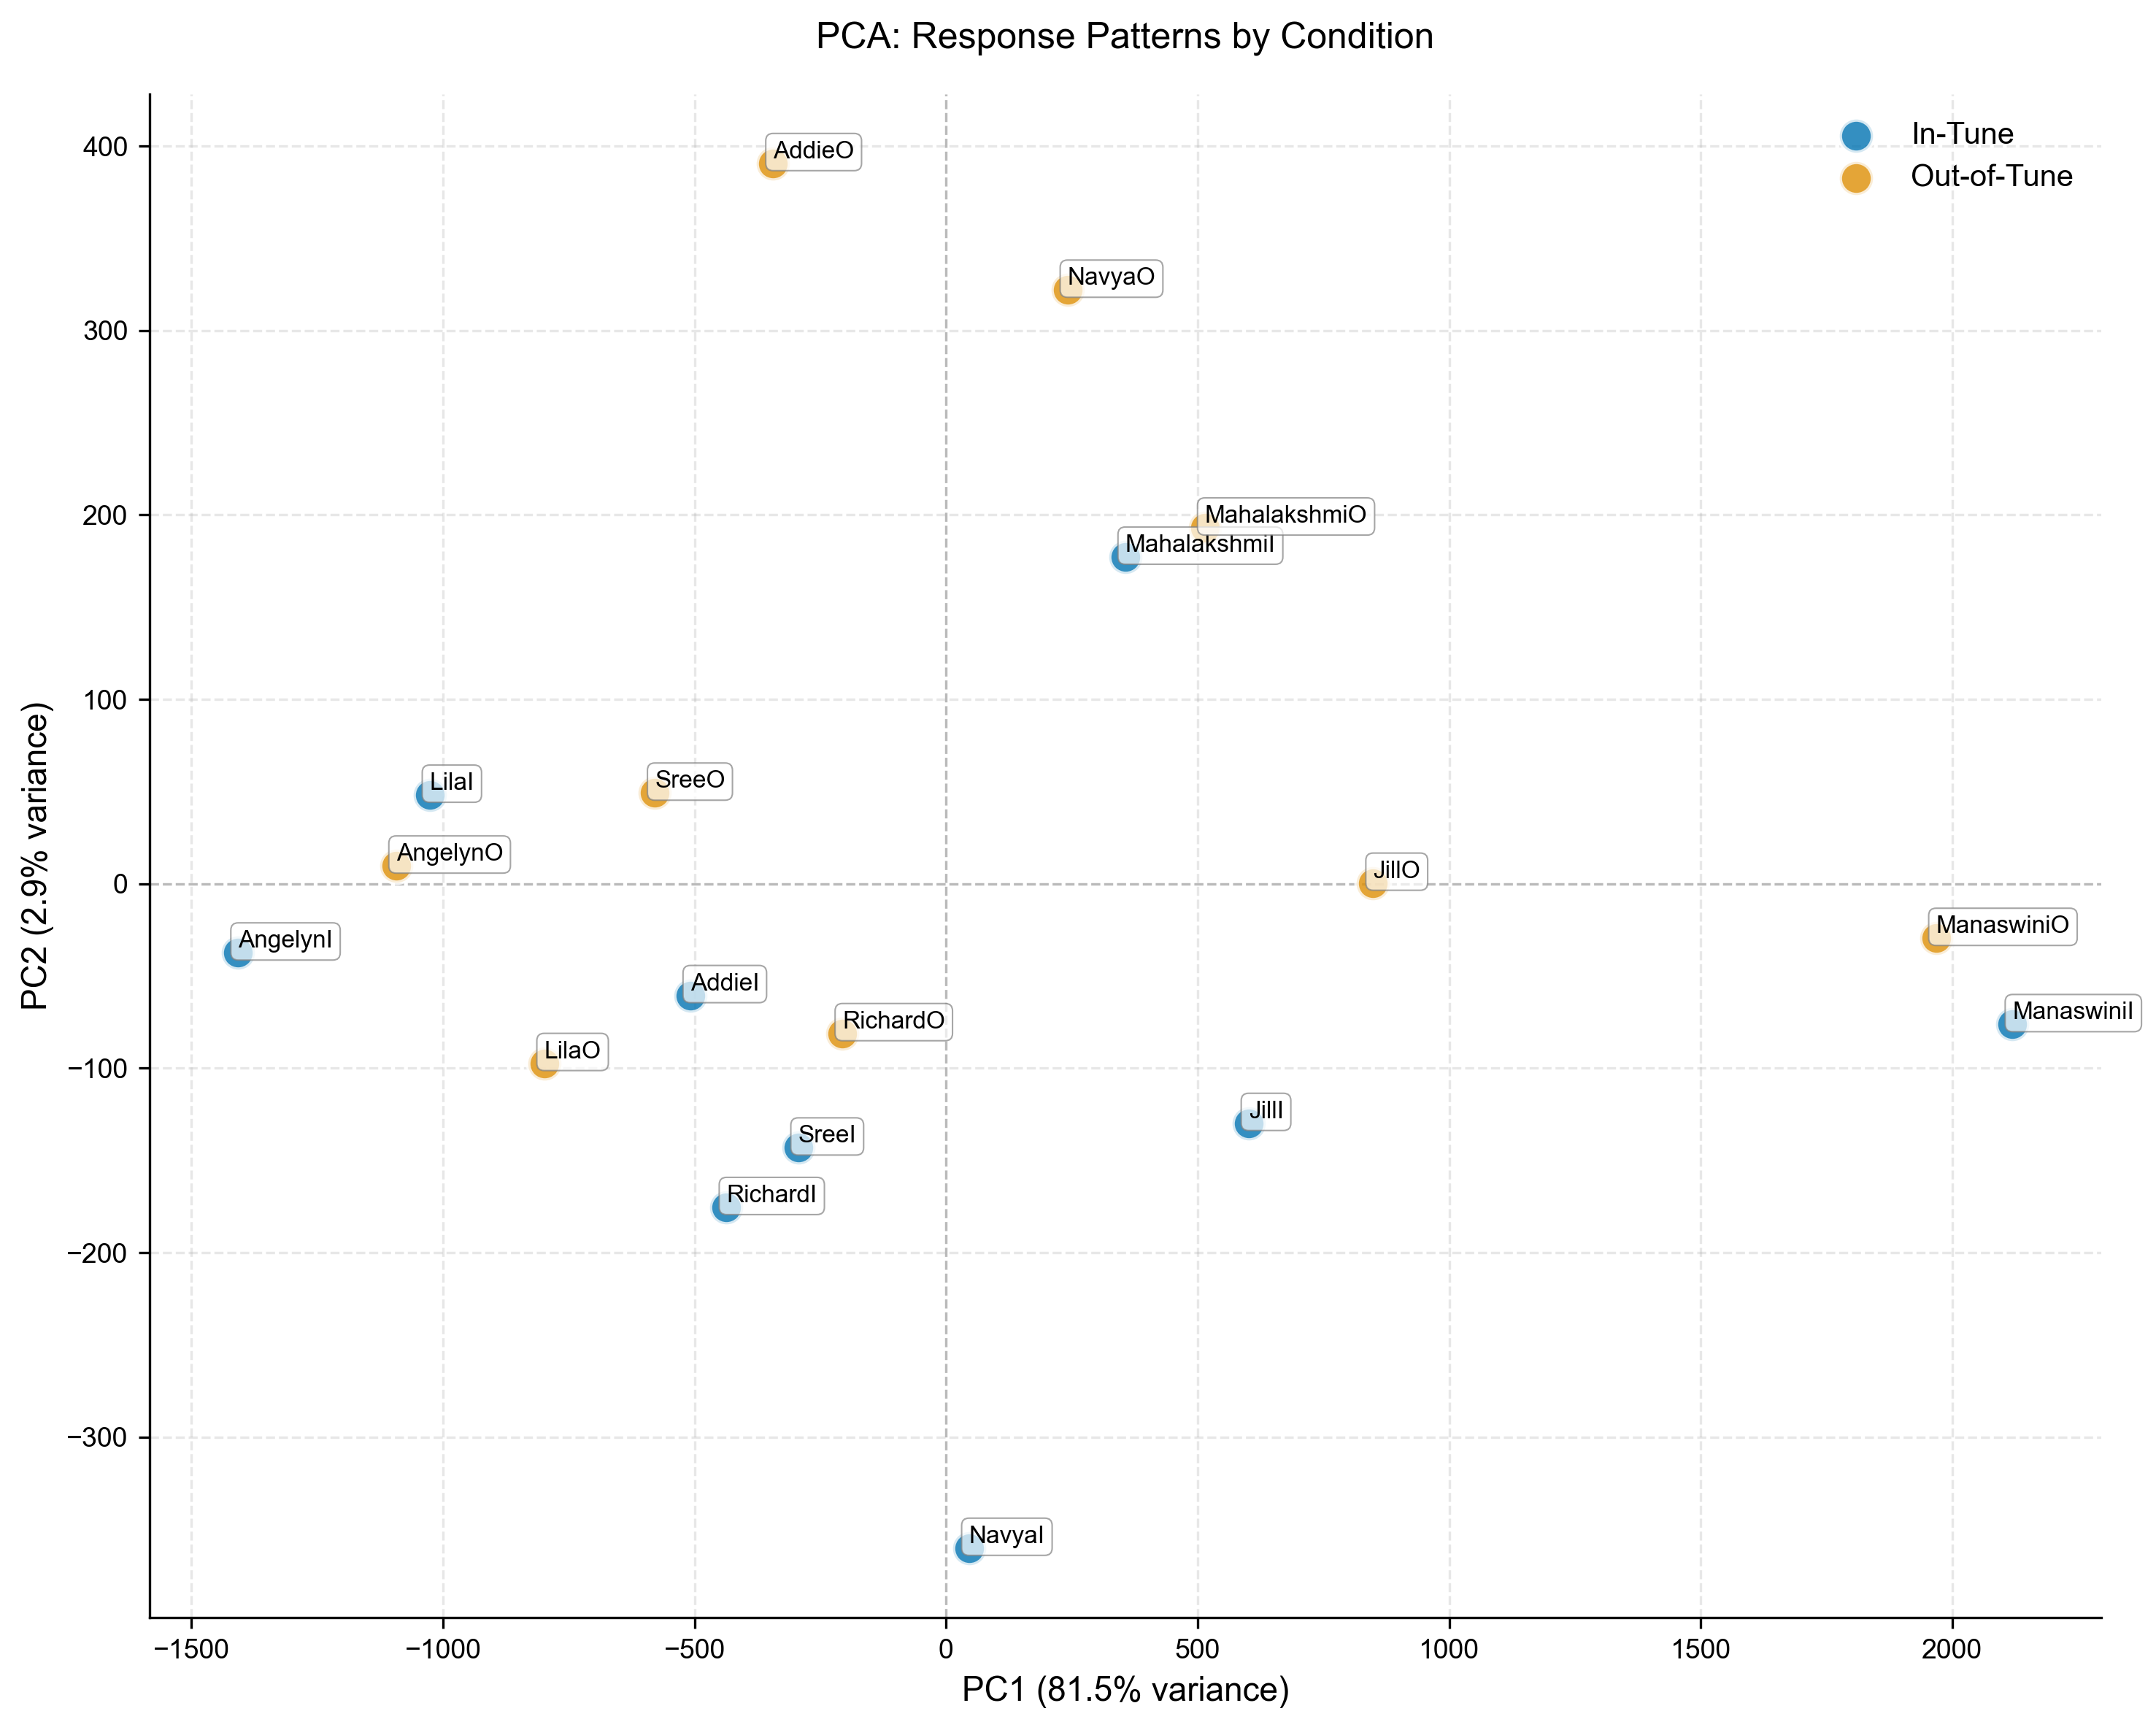

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for conditions
colors = {'I': '#0173B2', 'O': '#DE8F05'}  # Blue for In-Tune, Orange for Out-of-Tune
condition_names = {'I': 'In-Tune', 'O': 'Out-of-Tune'}

# Plot points by condition
for condition in ['I', 'O']:
    condition_data = pca_df[pca_df['Condition'] == condition]
    ax.scatter(condition_data['PC1'], condition_data['PC2'], 
               s=120, color=colors[condition], edgecolor='white', 
               linewidth=1.5, alpha=0.8, label=condition_names[condition],
               zorder=3)

# Annotate points with participant labels
for _, row in pca_df.iterrows():
    ax.text(row['PC1'] + 0.02, row['PC2'] + 0.02, row['Label'], 
            fontsize=8, ha='left', va='bottom', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='gray', alpha=0.7, linewidth=0.5))

# Add reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='normal')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='normal')
ax.set_title('PCA (2 Components)', fontweight='normal', pad=15)

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax.legend(frameon=False, loc='best')

plt.tight_layout()
# plt.savefig('pca_by_condition.pdf', format='pdf', bbox_inches='tight')
plt.savefig('pca_by_condition.png', format='png', bbox_inches='tight')
plt.show()

PCA ANALYSIS (3 COMPONENTS): IN-TUNE & OUT-OF-TUNE

Variance explained by PC1: 0.8150 (81.50%)
Variance explained by PC2: 0.0286 (2.86%)
Variance explained by PC3: 0.0261 (2.61%)
Total variance explained: 0.8697 (86.97%)

PCA Results (3 components):


,PC1,PC2,PC3,Label,Participant,Condition
0,-508.425816,-60.491664,289.603049,AddieI,Addie,I
1,-343.969382,390.595692,-391.067130,AddieO,Addie,O
2,-1407.282874,-37.389948,0.271498,AngelynI,Angelyn,I
3,-1093.244498,9.742989,167.086420,AngelynO,Angelyn,O
4,601.145131,-129.790258,-25.258101,JillI,Jill,I
5,848.852012,0.449188,171.096910,JillO,Jill,O
6,-1026.802303,48.154742,-106.810862,LilaI,Lila,I
7,-799.005887,-97.298873,-18.133809,LilaO,Lila,O
8,356.197593,177.212935,82.520690,MahalakshmiI,Mahalakshmi,I
9,514.276514,193.014672,-196.707522,MahalakshmiO,Mahalakshmi,O


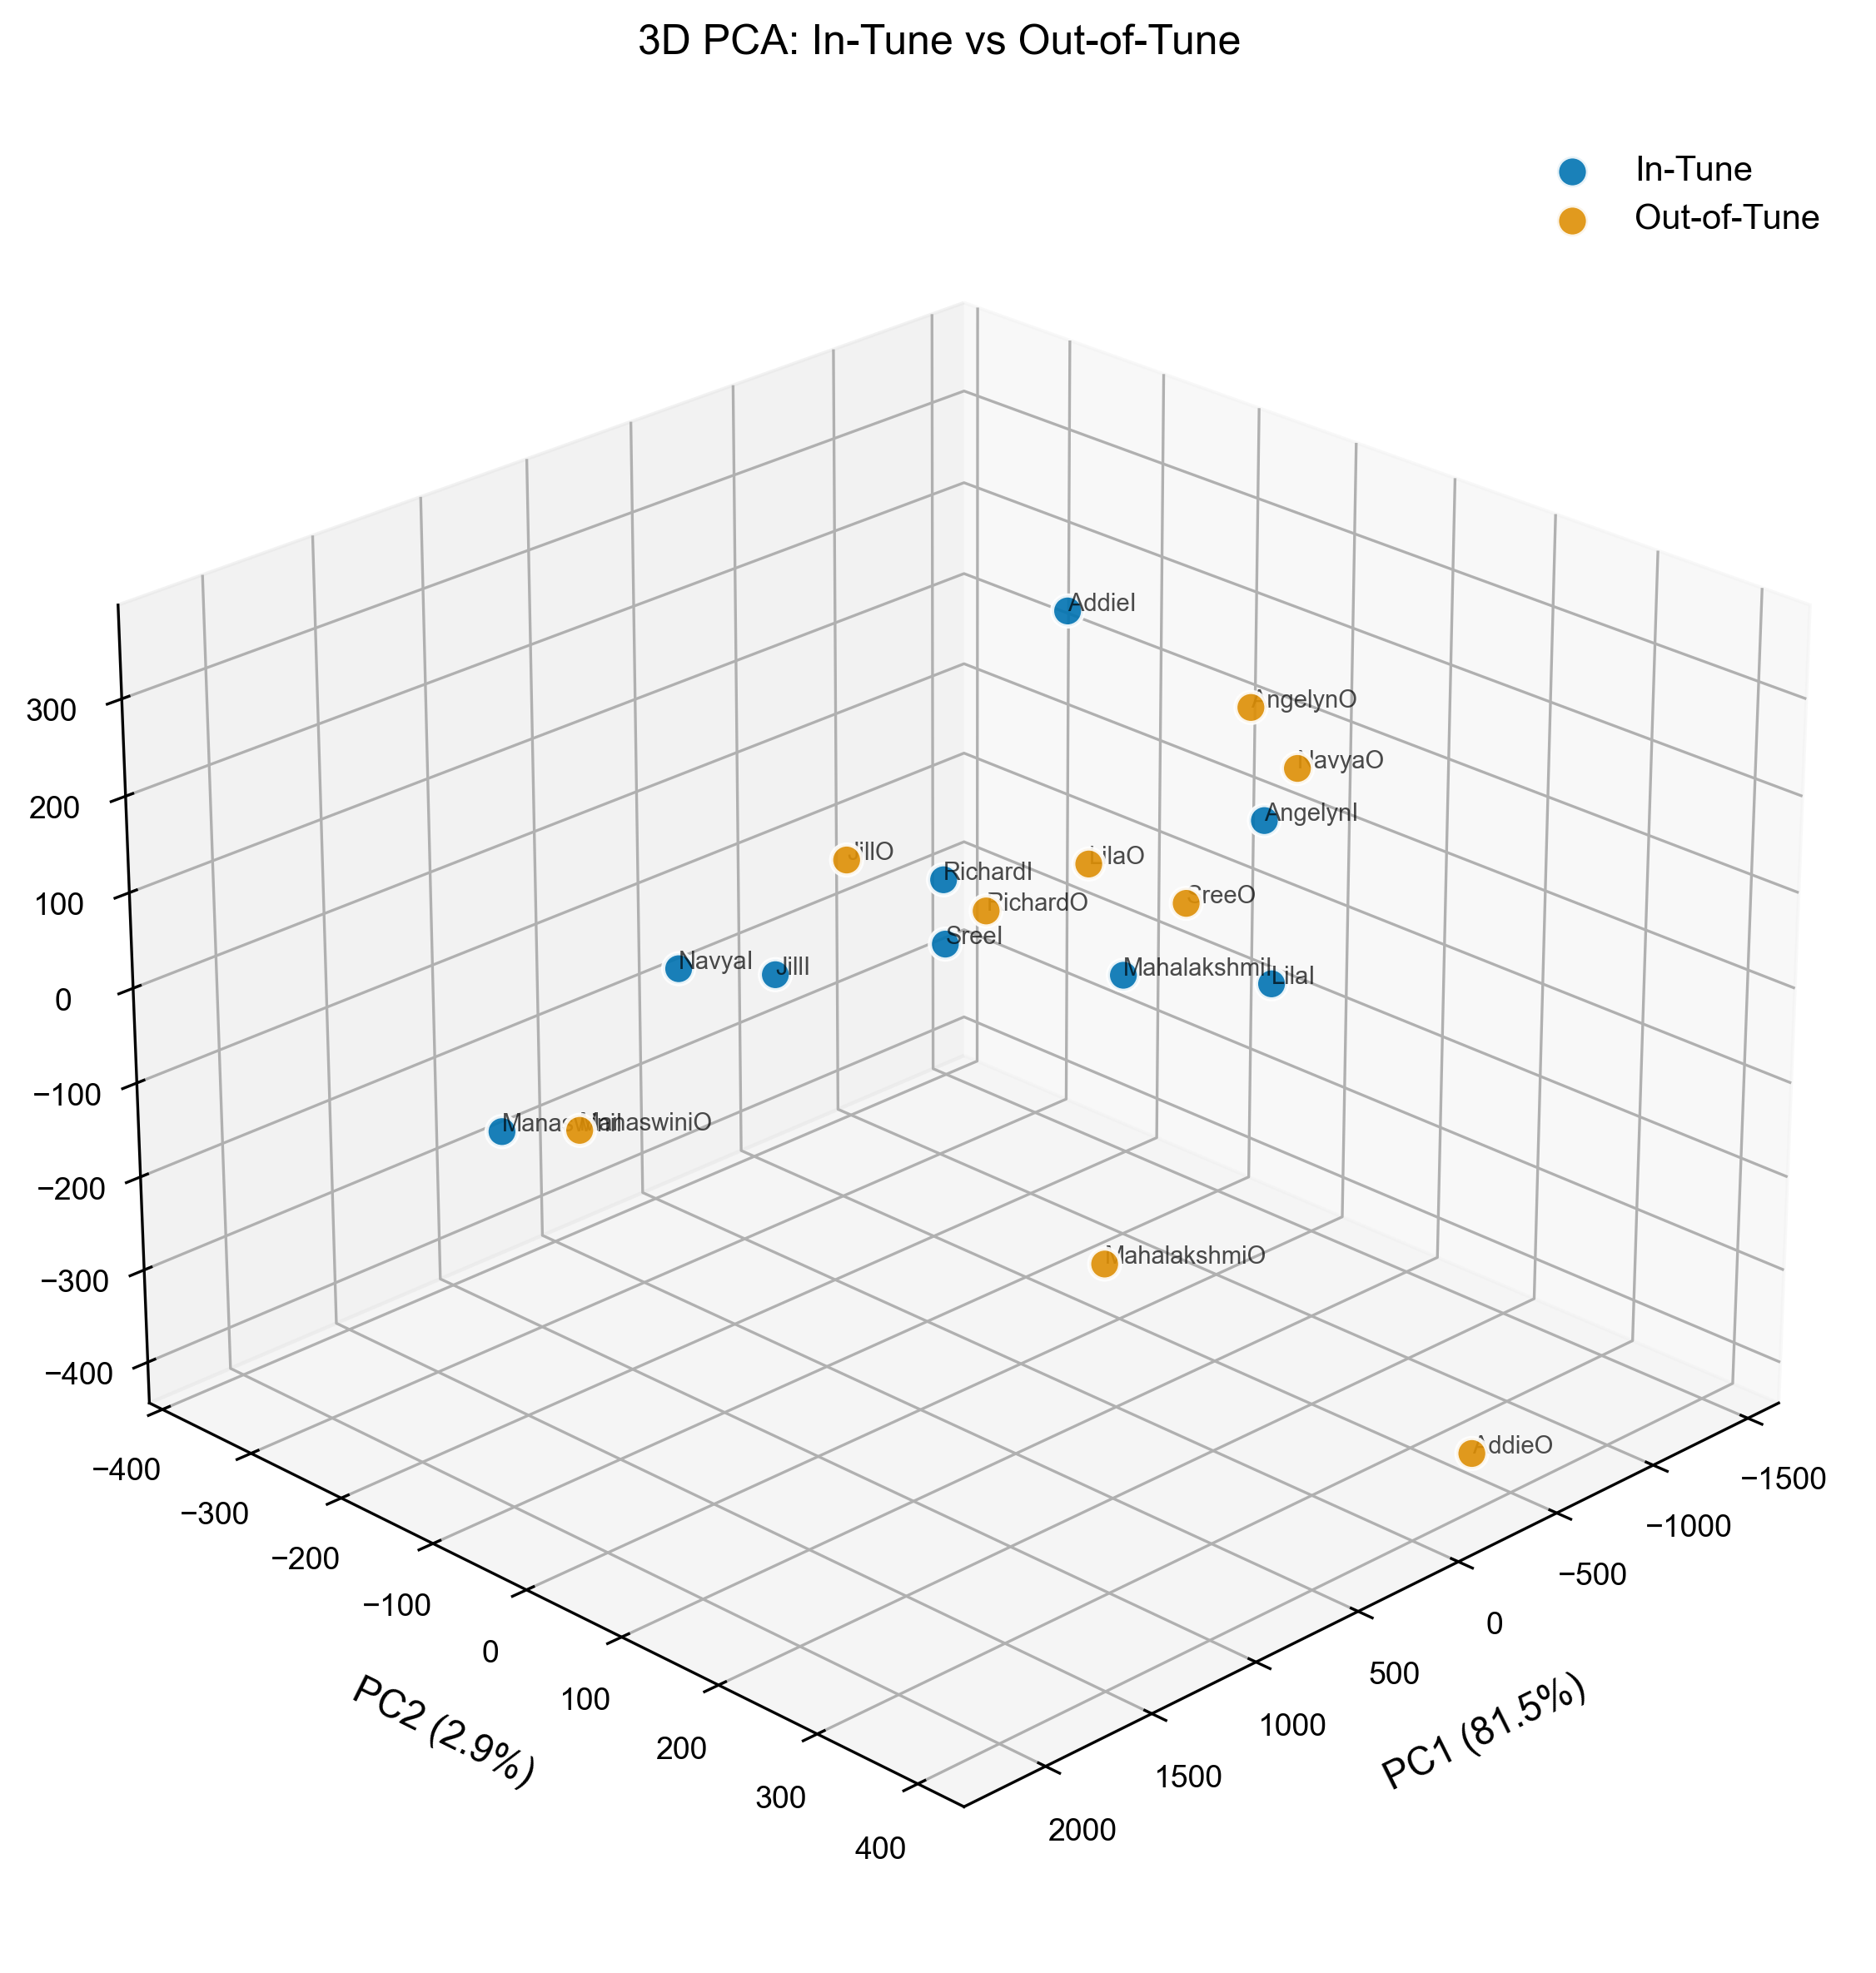

In [22]:
from mpl_toolkits.mplot3d import Axes3D

print("="*60)
print("PCA ANALYSIS (3 COMPONENTS): IN-TUNE & OUT-OF-TUNE")
print("="*60)

# Perform PCA with 3 components
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(rt_matrix_separate)

# Create DataFrame for plotting
pca3_df = pd.DataFrame(pca_result_3d, columns=['PC1', 'PC2', 'PC3'])
pca3_df['Label'] = labels_separate
pca3_df['Participant'] = pca3_df['Label'].str[:-1]
pca3_df['Condition'] = pca3_df['Label'].str[-1]

# Variance explained
var_exp = pca_3d.explained_variance_ratio_
print(f"\nVariance explained by PC1: {var_exp[0]:.4f} ({var_exp[0]*100:.2f}%)")
print(f"Variance explained by PC2: {var_exp[1]:.4f} ({var_exp[1]*100:.2f}%)")
print(f"Variance explained by PC3: {var_exp[2]:.4f} ({var_exp[2]*100:.2f}%)")
print(f"Total variance explained: {sum(var_exp):.4f} ({sum(var_exp)*100:.2f}%)")

print("\nPCA Results (3 components):")
display(pca3_df.head(10))

# Plot setup
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors for conditions
colors = {'I': '#0173B2', 'O': '#DE8F05'}
condition_names = {'I': 'In-Tune', 'O': 'Out-of-Tune'}

# Plot 3D scatter by condition
for condition in ['I', 'O']:
    data_cond = pca3_df[pca3_df['Condition'] == condition]
    ax.scatter(data_cond['PC1'], data_cond['PC2'], data_cond['PC3'],
               s=80, color=colors[condition], edgecolor='white',
               linewidth=1.2, alpha=0.9, label=condition_names[condition])

# Annotate participants (optional: comment out if cluttered)
for _, row in pca3_df.iterrows():
    ax.text(row['PC1'], row['PC2'], row['PC3'], row['Label'], fontsize=7, alpha=0.7)

# Label axes with variance explained
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({var_exp[2]*100:.1f}%)')

ax.set_title('3D PCA: In-Tune vs Out-of-Tune', pad=20)
ax.legend(frameon=False, loc='best')

# Styling
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 10
ax.grid(True, linestyle='--', alpha=0.3)
ax.view_init(elev=25, azim=45)  # Adjust angle for clarity

plt.tight_layout()
plt.savefig('pca_3d_by_condition.png', format='png', bbox_inches='tight')
plt.show()


In [16]:
from sklearn.manifold import MDS 

embedding = MDS (n_components=2, metric= False, n_init=2, max_iter=100, 
                 verbose=0, eps=0.001, n_jobs=2, random_state=101, 
                dissimilarity='euclidean')
#precip=precip[0:100]

out_similarity_df = embedding.fit_transform(out_similarity_df)
out_similarity_df

/Users/vidhyakshayakannan/.pyenv/versions/3.11.5/lib/python3.11/site-packages/sklearn/manifold/_mds.py:626: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


array([[-0.19286347, -0.24276561],
       [ 0.70286843,  0.79148301],
       [-0.01535626, -0.29756107],
       [ 0.07219779, -0.08175313],
       [-0.07926713,  0.09746622],
       [-0.17389097, -0.16585007],
       [-0.35355359, -0.09145856]])

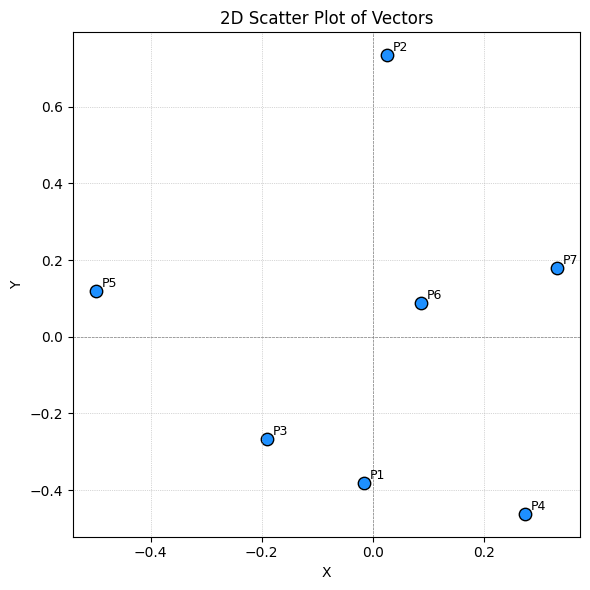

In [17]:
import matplotlib.pyplot as plt

# Coordinates
points = [
    [-0.01492294, -0.38194023],
    [ 0.02620121,  0.73389997],
    [-0.19038764, -0.2665932 ],
    [ 0.27492871, -0.46151489],
    [-0.49882925,  0.11971741],
    [ 0.08786149,  0.08890669],
    [ 0.33206932,  0.17859846]
]

x_vals = [x for x, y in points]
y_vals = [y for x, y in points]


plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals, color='dodgerblue', edgecolor='black', s=80)
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.grid(True, linestyle=':', linewidth=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Scatter Plot of Vectors")
for i, (x, y) in enumerate(points):
    plt.text(x + 0.01, y + 0.01, f"P{i+1}", fontsize=9)

plt.tight_layout()
plt.show()


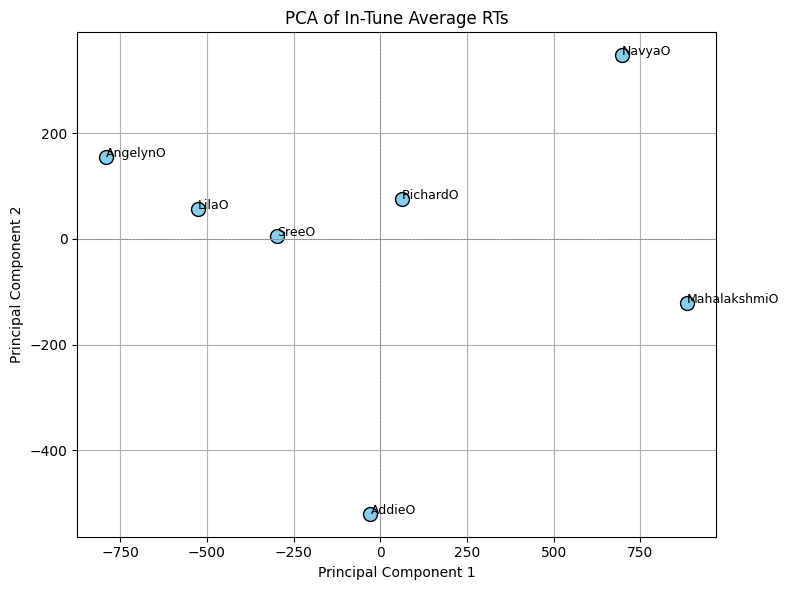

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on the original RT feature matrix
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(rt_matrix)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = participant_names

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, color='skyblue', edgecolor='black')

# Annotate each point
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('PCA of In-Tune Average RTs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


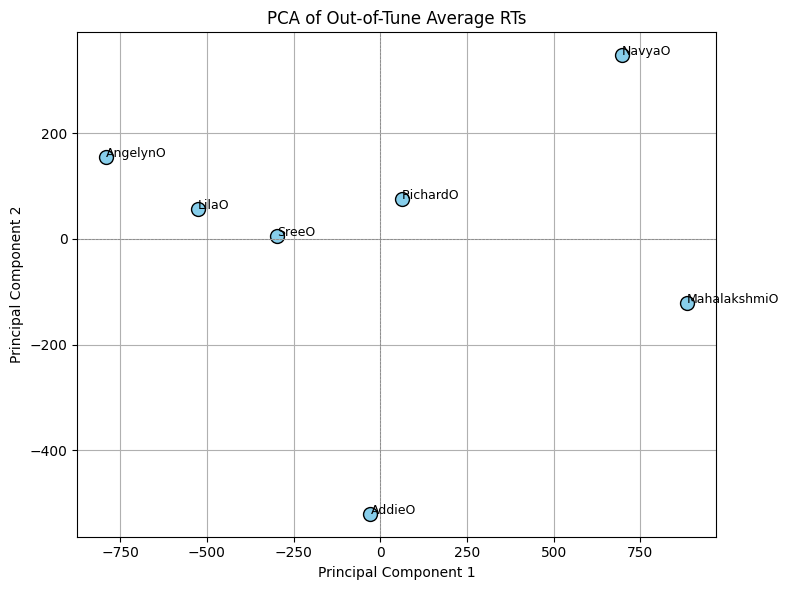

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on the original RT feature matrix
pca = PCA(n_components=2) 
pca_result = pca.fit_transform(out_rt_matrix)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = participant_names

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, color='skyblue', edgecolor='black')

# Annotate each point
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('PCA of Out-of-Tune Average RTs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


AngelynO -790.5057049343818 155.16942323528178 -77.3118834327866
AddieO -28.57670526671734 -520.4746345831578 -289.91715860140647
LilaO -525.5225817131605 56.546048559713114 159.34223423952338
MahalakshmiO 883.2593943332788 -121.65253907515769 307.71994771487385
NavyaO 695.9474855140866 347.95752630581165 -363.1911752517128
RichardO 62.622744044778564 75.87406712161071 204.47425985165847
SreeO -297.2246319778838 6.580108435897739 58.88377547985067


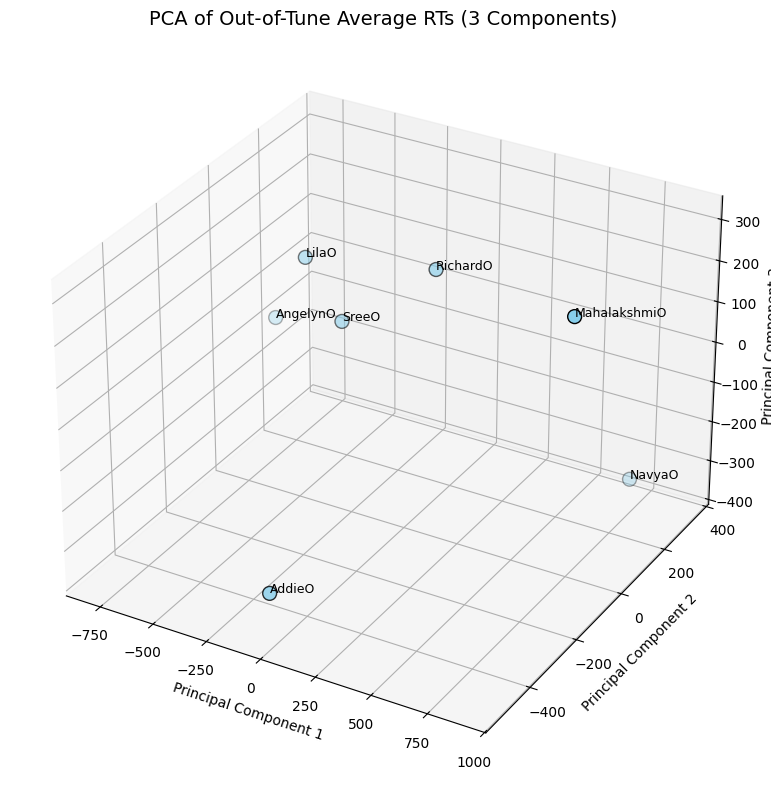

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
from sklearn.decomposition import PCA


pca = PCA(n_components=3)  
pca_result = pca.fit_transform(out_rt_matrix)


pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Participant'] = participant_names


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], s=100, color='skyblue', edgecolor='black')


for i, row in pca_df.iterrows():
    ax.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['PC3'] + 0.01, row['Participant'], fontsize=9)
    print(row['Participant'], row['PC1'], row['PC2'], row['PC3'])

ax.set_title('PCA of Out-of-Tune Average RTs (3 Components)', fontsize=14)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.tight_layout()
plt.show()


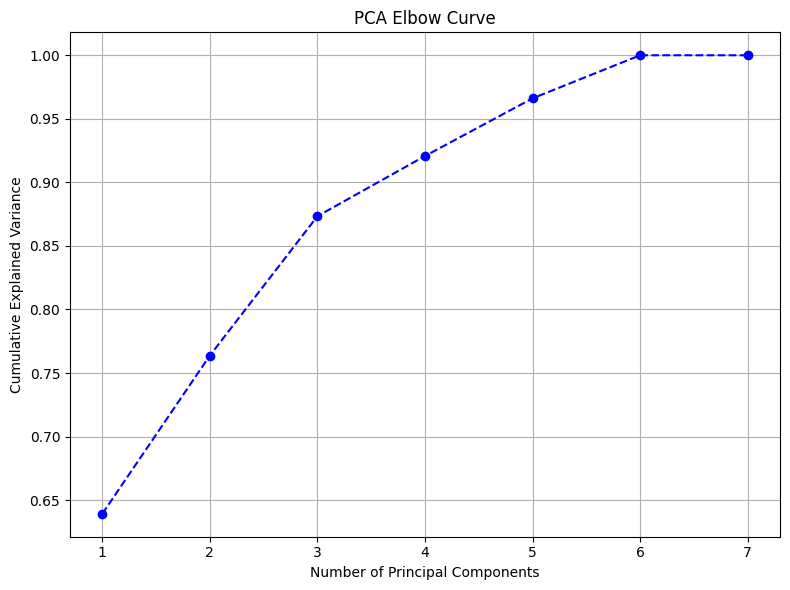

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


pca = PCA()
pca.fit(out_rt_matrix)

# When you run PCA, you're transforming your original features into new "principal components" (PCs).

#Each principal component explains a certain amount of the total variance (information) in your data.

# Explained Variance Ratio = Variance explained by a PC / Total variance in the data

# "How much information (variance) from the original data is captured by this particular principal component?"


explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Curve')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

cosine_distances = cosine_similarity(rt_matrix)

# Create labeled DataFrame
similarity_df = pd.DataFrame(cosine_distances, index=participant_names, columns=participant_names)

# Extract only the values (distance matrix)
distance_matrix = similarity_df.values

# Fit Agglomerative Clustering
model = AgglomerativeClustering(
    linkage='average',
    n_clusters=3
)
cluster_labels = model.fit_predict(distance_matrix)

# Add cluster labels to a *copy* of the similarity_df
result_df = similarity_df.copy()
result_df['Cluster'] = cluster_labels
print(result_df[['Cluster']])


              Cluster
AngelynO            0
AddieO              1
LilaO               0
MahalakshmiO        0
NavyaO              2
RichardO            0
SreeO               0


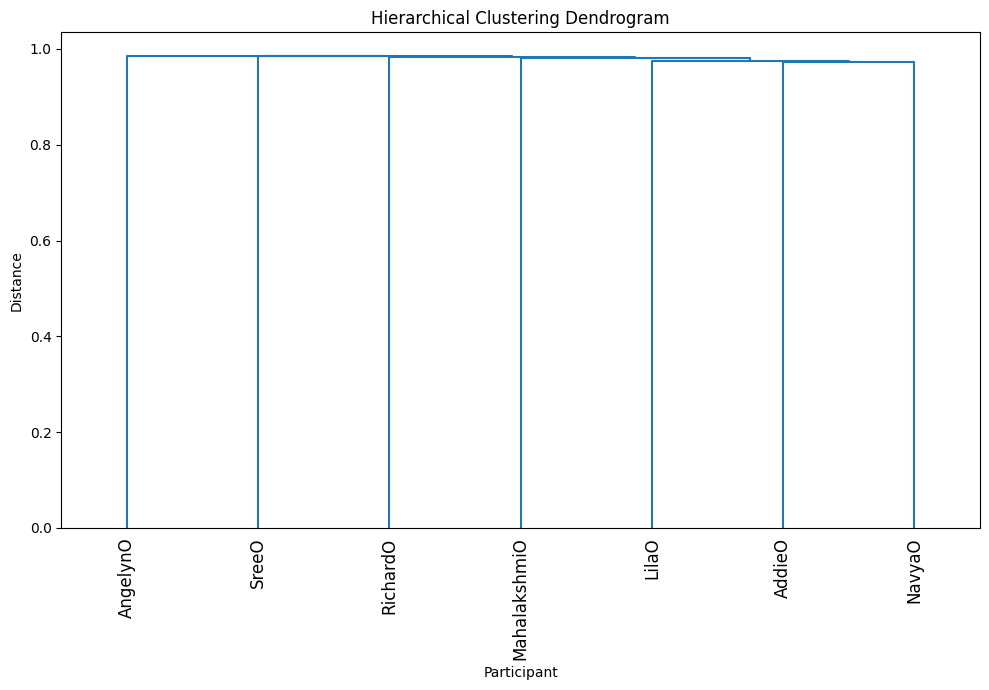

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Convert cosine similarity to cosine distance
cosine_distance = 1 - cosine_similarity(rt_matrix)

# linkage expects a condensed distance matrix (upper triangular part of the full distance matrix)
from scipy.spatial.distance import squareform
condensed_distance = squareform(cosine_similarity(rt_matrix), checks=False)


linkage_matrix = linkage(condensed_distance, method='average')


plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=participant_names, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Participant')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


1. Reproduce analysis for out of tunes.
2. See if I can get fit-by-dimension (elbow curve) for PCA
3

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# List of out-of-tune DataFrames and corresponding participant names
participant_dfs = {
    "Angelyn": angelyn_out_of_tune_df,
    "Addie": addie_out_of_tune_df,
    "Lila": lila_out_of_tune_df,
    "Mahalakshmi": mahalakshmi_out_of_tune_df,
    "Richard": richard_out_of_tune_df,
    "Sree": sree_out_of_tune_df
}

# Create a matrix where each row is a participant's out-of-tune average RTs
rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    col_name = f"{name}OutAveRT"
    rt_values = df[col_name].values
    rt_matrix.append(rt_values)
    participant_names.append(name+"O")


out_rt_matrix_new = np.array(rt_matrix)
out_similarity_matrix_new = 1 - cosine_similarity(rt_matrix)
out_similarity_df_new = pd.DataFrame(out_similarity_matrix_new, index=participant_names, columns=participant_names)

print("Cosine Similarity Matrix (Out-of-Tune Average RTs):")
print(out_similarity_df_new.round(4)) 


Cosine Similarity Matrix (Out-of-Tune Average RTs):
              AngelynO  AddieO   LilaO  MahalakshmiO  RichardO   SreeO
AngelynO        0.0000  0.0231  0.0157        0.0151    0.0101  0.0113
AddieO          0.0231  0.0000  0.0259        0.0219    0.0241  0.0206
LilaO           0.0157  0.0259 -0.0000        0.0160    0.0113  0.0145
MahalakshmiO    0.0151  0.0219  0.0160        0.0000    0.0135  0.0139
RichardO        0.0101  0.0241  0.0113        0.0135    0.0000  0.0104
SreeO           0.0113  0.0206  0.0145        0.0139    0.0104 -0.0000


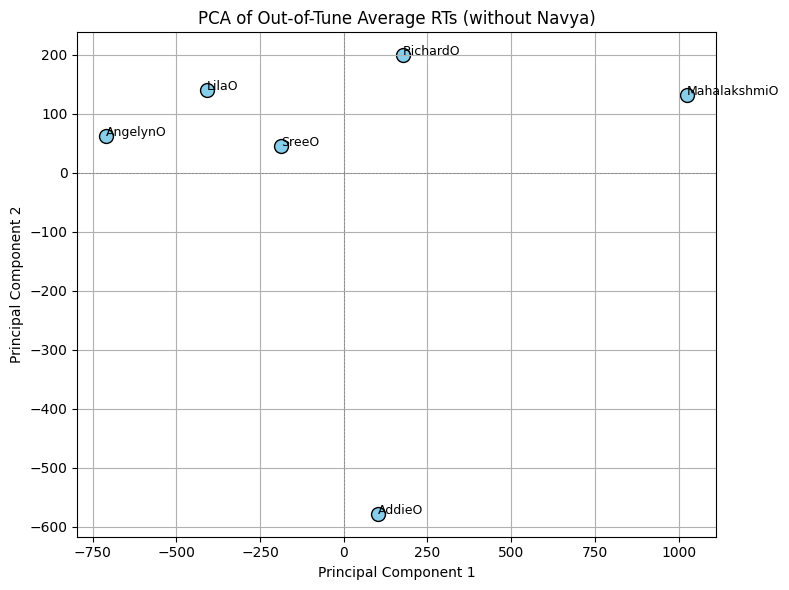

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on the original RT feature matrix
pca = PCA(n_components=2) 
pca_result = pca.fit_transform(out_rt_matrix_new)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = participant_names

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, color='skyblue', edgecolor='black')

# Annotate each point
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('PCA of Out-of-Tune Average RTs (without Navya)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

participants = ["Angelyn", "Addie", "Lila", "Mahalakshmi", "Richard", "Sree"]

combined_rt_matrix = []
combined_names = []

for name in participants:
    # Read CSVs
    in_df = pd.read_csv(f"{name.lower()}_in_tune_avg_rt.csv")
    out_df = pd.read_csv(f"{name.lower()}_out_of_tune_avg_rt.csv")

    # In-Tune RTs
    in_rt = in_df[f"{name}InAveRT"].values
    combined_rt_matrix.append(in_rt)
    combined_names.append(name + "I")

    # Out-Of-Tune RTs
    out_rt = out_df[f"{name}OutAveRT"].values
    combined_rt_matrix.append(out_rt)
    combined_names.append(name + "O")

# Convert to numpy array
combined_rt_matrix_new= np.array(combined_rt_matrix)

# Calculate cosine similarity across all (In & Out)
similarity_matrix = 1 - cosine_similarity(combined_rt_matrix_new)

# Create DataFrame for display
combined_similarity_df_new = pd.DataFrame(similarity_matrix, index=combined_names, columns=combined_names)

print("Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):")
print(combined_similarity_df_new.round(4))


Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):
              AngelynI  AngelynO  AddieI  AddieO   LilaI   LilaO  \
AngelynI        0.0000    0.0095  0.0241  0.0219  0.0091  0.0176   
AngelynO        0.0095    0.0000  0.0135  0.0231  0.0108  0.0157   
AddieI          0.0241    0.0135  0.0000  0.0310  0.0224  0.0212   
AddieO          0.0219    0.0231  0.0310  0.0000  0.0136  0.0259   
LilaI           0.0091    0.0108  0.0224  0.0136  0.0000  0.0155   
LilaO           0.0176    0.0157  0.0212  0.0259  0.0155 -0.0000   
MahalakshmiI    0.0114    0.0095  0.0225  0.0231  0.0145  0.0179   
MahalakshmiO    0.0169    0.0151  0.0237  0.0219  0.0138  0.0160   
RichardI        0.0132    0.0120  0.0210  0.0248  0.0124  0.0148   
RichardO        0.0122    0.0101  0.0204  0.0241  0.0096  0.0113   
SreeI           0.0124    0.0107  0.0211  0.0261  0.0147  0.0124   
SreeO           0.0083    0.0113  0.0173  0.0206  0.0104  0.0145   

              MahalakshmiI  MahalakshmiO  RichardI  Rich

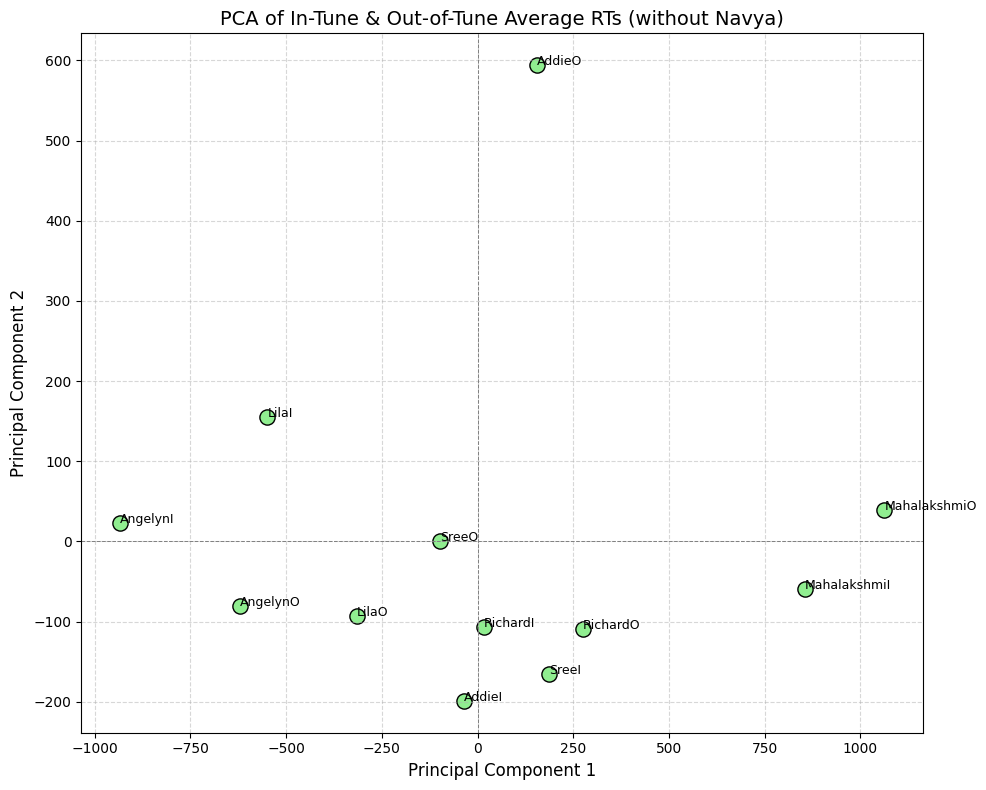

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Perform PCA on the combined RT matrix (In-Tune + Out-of-Tune)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_rt_matrix_new)

# Create DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = combined_names  # Eg. ['AngelynI', 'AngelynO', ...]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=120, color='lightgreen', edgecolor='black')

# Annotate points
for _, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.title('PCA of In-Tune & Out-of-Tune Average RTs (without Navya)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

participants = ["Angelyn", "Lila", "Mahalakshmi", "Richard", "Sree"]

combined_rt_matrix = []
combined_names = []

for name in participants:
    # Read CSVs
    in_df = pd.read_csv(f"{name.lower()}_in_tune_avg_rt.csv")
    out_df = pd.read_csv(f"{name.lower()}_out_of_tune_avg_rt.csv")

    # In-Tune RTs
    in_rt = in_df[f"{name}InAveRT"].values
    combined_rt_matrix.append(in_rt)
    combined_names.append(name + "I")

    # Out-Of-Tune RTs
    out_rt = out_df[f"{name}OutAveRT"].values
    combined_rt_matrix.append(out_rt)
    combined_names.append(name + "O")

# Convert to numpy array
combined_rt_matrix_without_addie= np.array(combined_rt_matrix)

# Calculate cosine similarity across all (In & Out)
similarity_matrix = 1 - cosine_similarity(combined_rt_matrix_without_addie)

# Create DataFrame for display
combined_similarity_df_without_addie = pd.DataFrame(similarity_matrix, index=combined_names, columns=combined_names)

print("Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):")
print(combined_similarity_df_without_addie.round(4))


Cosine Similarity Matrix (In-Tune & Out-of-Tune Combined):
              AngelynI  AngelynO   LilaI   LilaO  MahalakshmiI  MahalakshmiO  \
AngelynI        0.0000    0.0095  0.0091  0.0176        0.0114        0.0169   
AngelynO        0.0095    0.0000  0.0108  0.0157        0.0095        0.0151   
LilaI           0.0091    0.0108  0.0000  0.0155        0.0145        0.0138   
LilaO           0.0176    0.0157  0.0155 -0.0000        0.0179        0.0160   
MahalakshmiI    0.0114    0.0095  0.0145  0.0179       -0.0000        0.0154   
MahalakshmiO    0.0169    0.0151  0.0138  0.0160        0.0154        0.0000   
RichardI        0.0132    0.0120  0.0124  0.0148        0.0155        0.0184   
RichardO        0.0122    0.0101  0.0096  0.0113        0.0130        0.0135   
SreeI           0.0124    0.0107  0.0147  0.0124        0.0137        0.0115   
SreeO           0.0083    0.0113  0.0104  0.0145        0.0103        0.0139   

              RichardI  RichardO   SreeI   SreeO  
AngelynI 

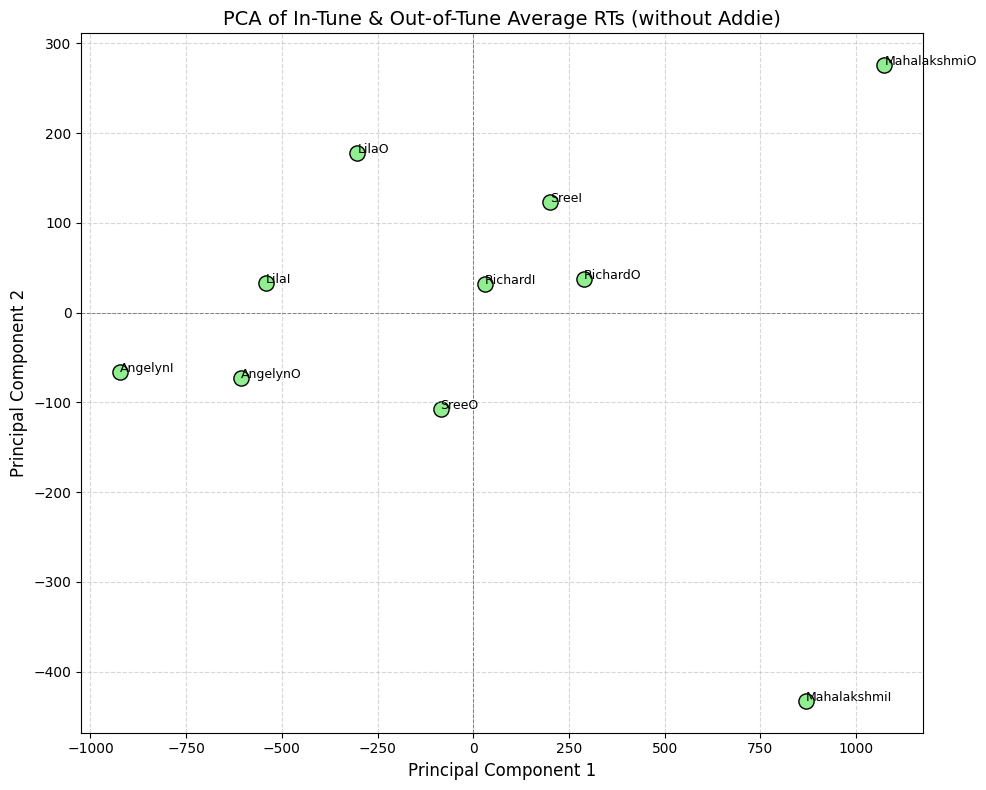

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Perform PCA on the combined RT matrix (In-Tune + Out-of-Tune)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_rt_matrix_without_addie)

# Create DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = combined_names  # Eg. ['AngelynI', 'AngelynO', ...]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=120, color='lightgreen', edgecolor='black')

# Annotate points
for _, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.title('PCA of In-Tune & Out-of-Tune Average RTs (without Addie)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- Plot in 3D (PCA)
- Figure out how to plot agglomerative clustering. 

- Average the standards score for in tune and out of tune for EACH subject. 
- See if downward trend following gap is universal. 
- Perform PCA 

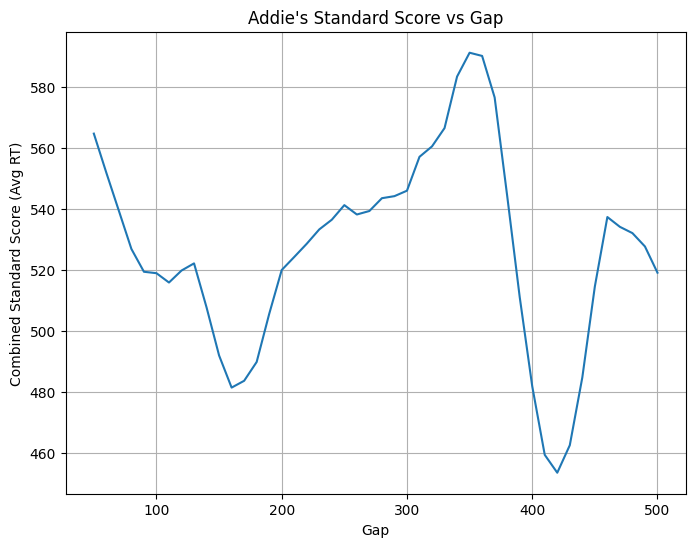

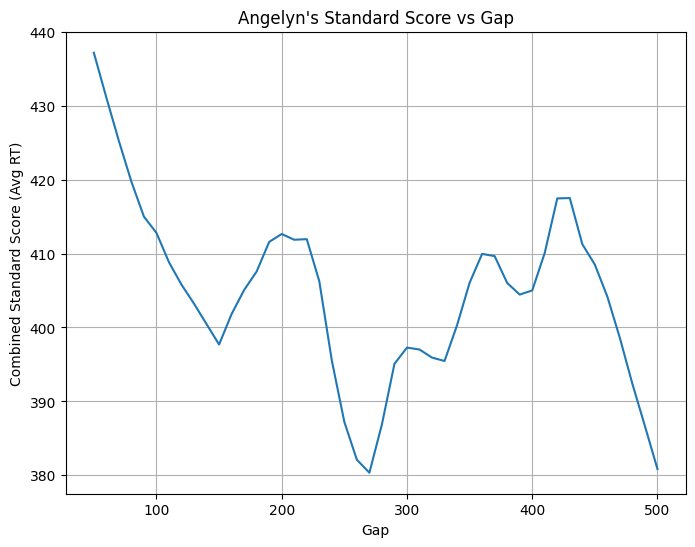

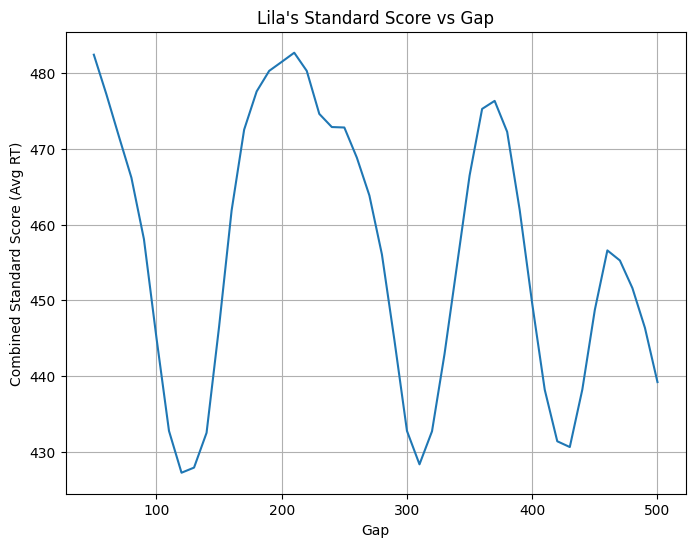

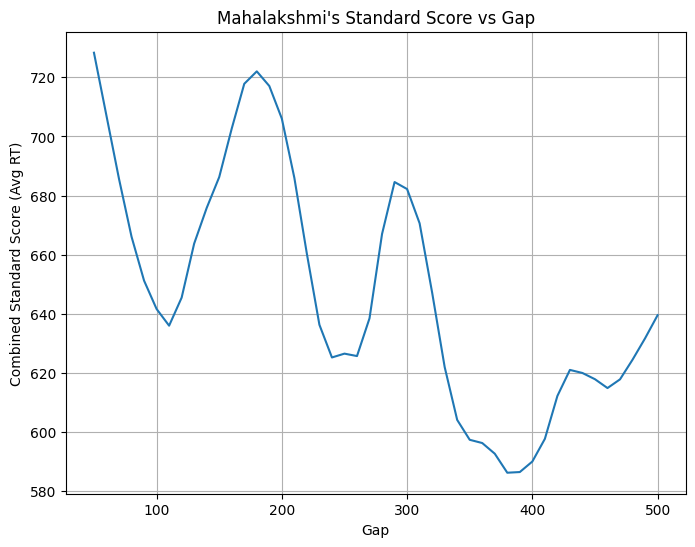

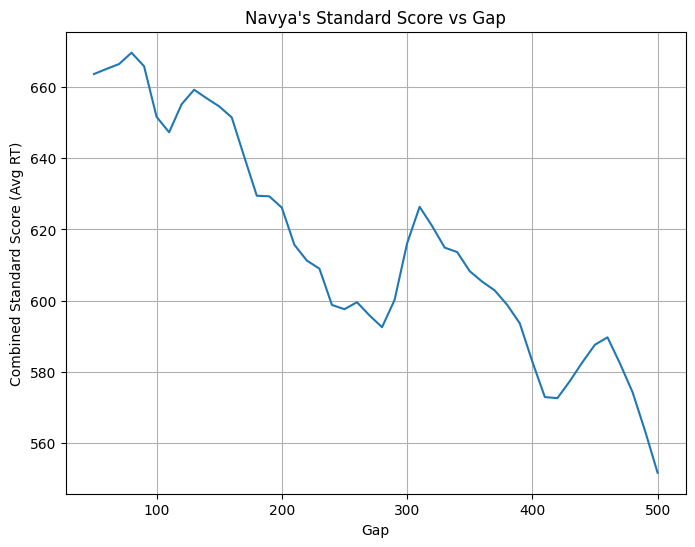

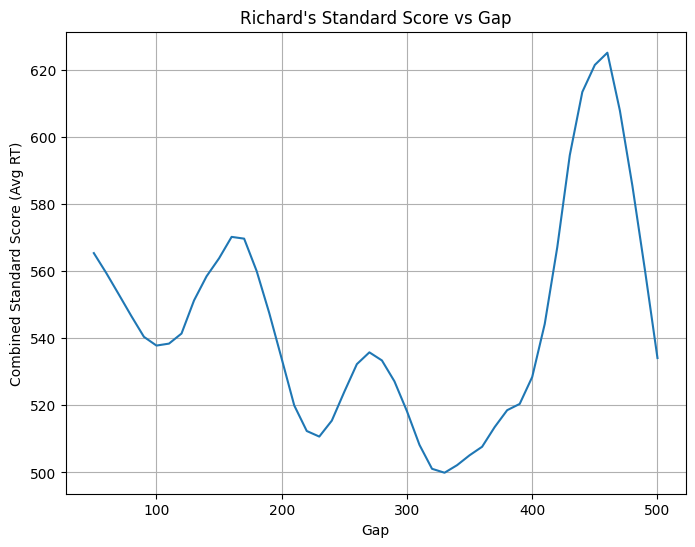

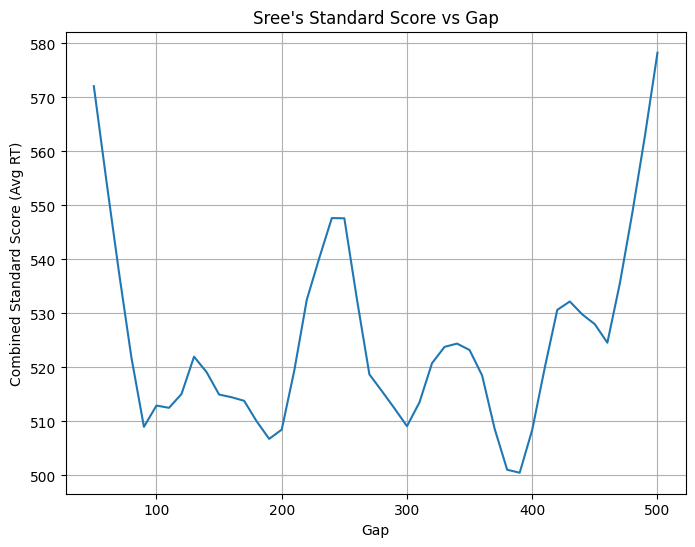

In [30]:
from statsmodels.nonparametric.smoothers_lowess import lowess

paths = {
    'addie': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/addie',
    'angelyn': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/angelyn',
    'lila': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/lila',
    'mahalakshmi': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/mahalakshmi',
    'navya': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/navya',
    'richard': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/richard',
    'sree': '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/Sree'
}


def process_participant_data(participant):
    in_tune_path = f"{paths[participant]}/{participant}_in_tune_avg_rt.csv"
    out_of_tune_path = f"{paths[participant]}/{participant}_out_of_tune_avg_rt.csv"
    in_tune_df = pd.read_csv(in_tune_path)
    out_of_tune_df = pd.read_csv(out_of_tune_path)
    merged_df = pd.merge(in_tune_df, out_of_tune_df, on='Gap')
    merged_df['CombinedAvgRT'] = merged_df[[f'{participant.title()}InAveRT', 'OutAveRT']].mean(axis=1)
    smoothed = lowess(merged_df['CombinedAvgRT'], merged_df['Gap'], frac=0.2)
    output_path = f"{paths[participant]}/{participant}_in_tune_out_of_tune_combined_avg_rt.csv"
    merged_df.to_csv(output_path, index=False)
    plt.figure(figsize=(8, 6))
    plt.plot(merged_df['Gap'], smoothed[:, 1], label='Smoothed Curve')
    plt.title(f"{participant.capitalize()}'s Standard Score vs Gap")
    plt.xlabel('Gap')
    plt.ylabel('Combined Standard Score (Avg RT)')
    plt.grid(True)
    plt.savefig(f"{paths[participant]}/{participant}_standard_score_vs_gap.png")
    plt.show()

for participant in ['addie', 'angelyn', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree']:
    process_participant_data(participant)


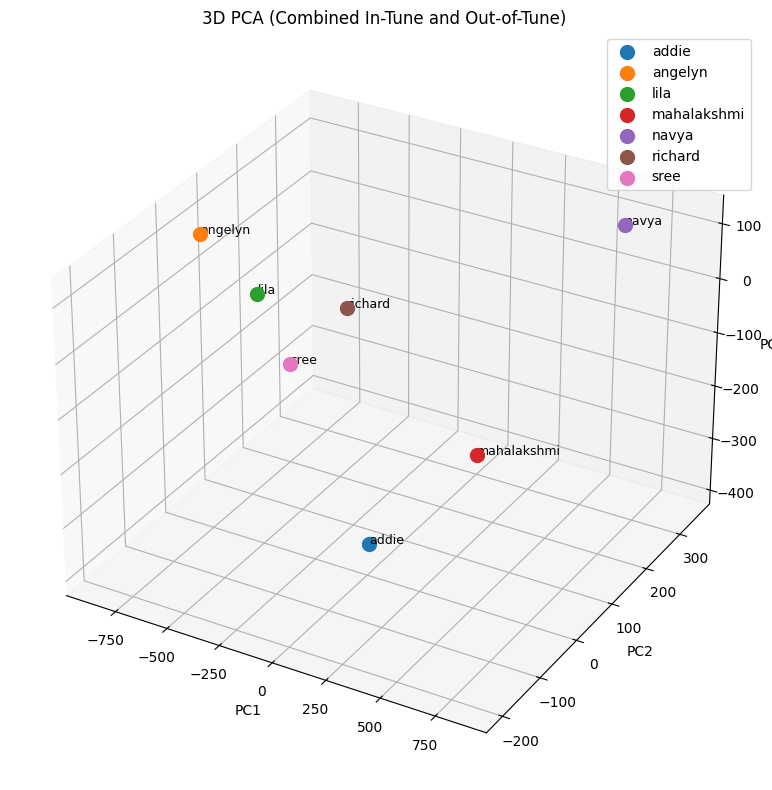

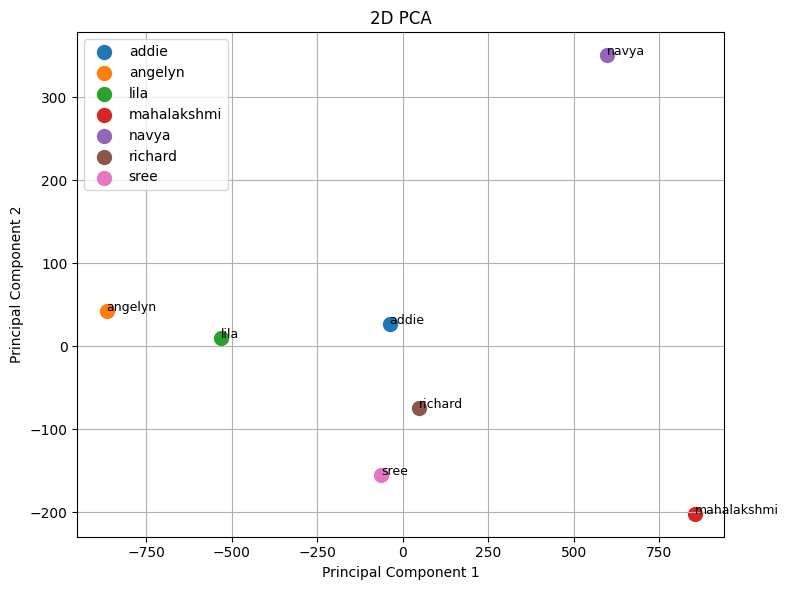

In [31]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Participant info and data path
participants = ['addie', 'angelyn', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree']
base_path = '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'

# Load combined avg RTs for each participant
combined_data = []

for participant in participants:
    try:
        path = f"{base_path}/{participant}/{participant}_in_tune_out_of_tune_combined_avg_rt.csv"
        df = pd.read_csv(path)[['Gap', 'CombinedAvgRT']].copy()
        df.rename(columns={'CombinedAvgRT': participant}, inplace=True)
        combined_data.append(df)
    except FileNotFoundError:
        print(f"{participant} file not found. Skipping...")

# Merge on 'Gap'
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

# Transpose so each row = participant, each column = Gap
data_by_participant = merged_df.drop(columns='Gap').T
data_by_participant.columns = [f"Gap_{g}" for g in merged_df['Gap']]  # Clear feature labels

# PCA without scaling
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(data_by_participant)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, participant in enumerate(participants):
    ax.scatter(X_pca_3d[i, 0], X_pca_3d[i, 1], X_pca_3d[i, 2], label=participant, s=100)
    ax.text(X_pca_3d[i, 0]+0.1, X_pca_3d[i, 1]+0.1, X_pca_3d[i, 2]+0.1, participant, fontsize=9)

ax.set_title('3D PCA (Combined In-Tune and Out-of-Tune)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.legend()
plt.tight_layout()
plt.show()

# 2D PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(data_by_participant)

# 2D plot
plt.figure(figsize=(8, 6))
for i, participant in enumerate(participants):
    plt.scatter(X_pca_2d[i, 0], X_pca_2d[i, 1], label=participant, s=100)
    plt.text(X_pca_2d[i, 0] + 0.05, X_pca_2d[i, 1], participant, fontsize=9)

plt.title('2D PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Participant info and data path
participants = ['angelyn', 'lila', 'navya', 'richard', 'sree']
base_path = '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'

# Load combined avg RTs for each participant
combined_data = []
combined_data_sum = pd.DataFrame()

for participant in participants:
    try:
        path = f"{base_path}/{participant}/{participant}_in_tune_out_of_tune_combined_avg_rt.csv"
        df = pd.read_csv(path)[['Gap', 'CombinedAvgRT']].copy()
        df.rename(columns={'CombinedAvgRT': participant}, inplace=True)
        combined_data.append(df)
        combined_data_sum = combined_data_sum + df['CombinedAvgRT']
        print(combined_data_sum)
        combined_data_sum = combined_data_sum + combined_data
    except FileNotFoundError:
        print(f"{participant} file not found. Skipping...")
    



# Merge on 'Gap'
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

# Transpose so each row = participant, each column = Gap
data_by_participant = merged_df.drop(columns='Gap').T
data_by_participant.columns = [f"Gap_{g}" for g in merged_df['Gap']]  # Clear feature labels

# PCA without scaling
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(data_by_participant)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, participant in enumerate(participants):
    ax.scatter(X_pca_3d[i, 0], X_pca_3d[i, 1], X_pca_3d[i, 2], label=participant, s=100)
    ax.text(X_pca_3d[i, 0]+0.1, X_pca_3d[i, 1]+0.1, X_pca_3d[i, 2]+0.1, participant, fontsize=9)

ax.set_title('3D PCA (Combined In-Tune and Out-of-Tune)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.legend()
plt.tight_layout()
plt.show()

# 2D PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(data_by_participant)

# 2D plot
plt.figure(figsize=(8, 6))
for i, participant in enumerate(participants):
    plt.scatter(X_pca_2d[i, 0], X_pca_2d[i, 1], label=participant, s=100)
    plt.text(X_pca_2d[i, 0] + 0.05, X_pca_2d[i, 1], participant, fontsize=9)

plt.title('2D PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'CombinedAvgRT'

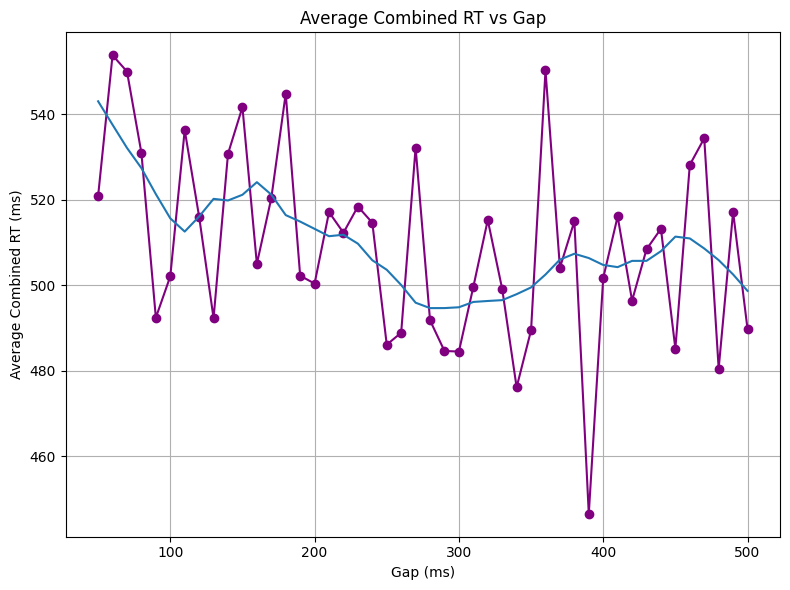

In [38]:
import pandas as pd
import matplotlib.pyplot as plt


# Participant info and data path
participants = ['angelyn', 'lila', 'navya', 'richard', 'sree']
base_path = '/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'

# Load combined avg RTs for each participant
combined_data = []

for participant in participants:
    try:
        path = f"{base_path}/{participant}/{participant}_in_tune_out_of_tune_combined_avg_rt.csv"
        df = pd.read_csv(path)[['Gap', 'CombinedAvgRT']].copy()
        df.rename(columns={'CombinedAvgRT': participant}, inplace=True)
        combined_data.append(df)
    except FileNotFoundError:
        print(f"{participant} file not found. Skipping...")

# Merge all on 'Gap'
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

# Compute the average CombinedAvgRT across participants
merged_df['AvgCombinedRT'] = merged_df[participants].mean(axis=1)
smoothed = lowess(merged_df['AvgCombinedRT'], merged_df['Gap'], frac=0.2)
 
# Plot AvgCombinedRT vs Gap
plt.figure(figsize=(8, 6))
plt.plot(merged_df['Gap'], merged_df['AvgCombinedRT'], marker = 'o', color='purple')
plt.plot(merged_df['Gap'], smoothed[:, 1], label='Smoothed Curve')
plt.title('Average Combined RT vs Gap')
plt.xlabel('Gap (ms)')
plt.ylabel('Average Combined RT (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()


Removed outliers: RT < 212.38 or RT > 2099.38
Remaining data points: 245

Average Reaction Time by Gap:
    Gap   Average_RT
0    50  1115.500000
1    60  1100.500000
2    70  1113.500000
3    80   978.600000
4    90  1252.166667
5   100  1277.200000
6   110  1018.800000
7   120  1001.666667
8   130  1181.750000
9   140  1092.750000
10  150  1137.000000
11  160  1169.500000
12  170  1163.000000
13  180  1027.166667
14  190   971.500000
15  200  1144.200000
16  210  1178.666667
17  220  1145.000000
18  230  1117.000000
19  240  1170.800000
20  250  1033.166667
21  260  1163.750000
22  270  1203.000000
23  280  1216.750000
24  290  1110.500000
25  300  1327.833333
26  310  1385.200000
27  320  1076.400000
28  330  1197.666667
29  340  1168.333333
30  350   946.333333
31  360  1094.600000
32  370  1096.750000
33  380  1118.333333
34  390  1193.000000
35  400   977.666667
36  410  1118.833333
37  420  1132.500000
38  430   994.200000
39  440  1089.800000
40  450  1009.800000
41  460  1133.

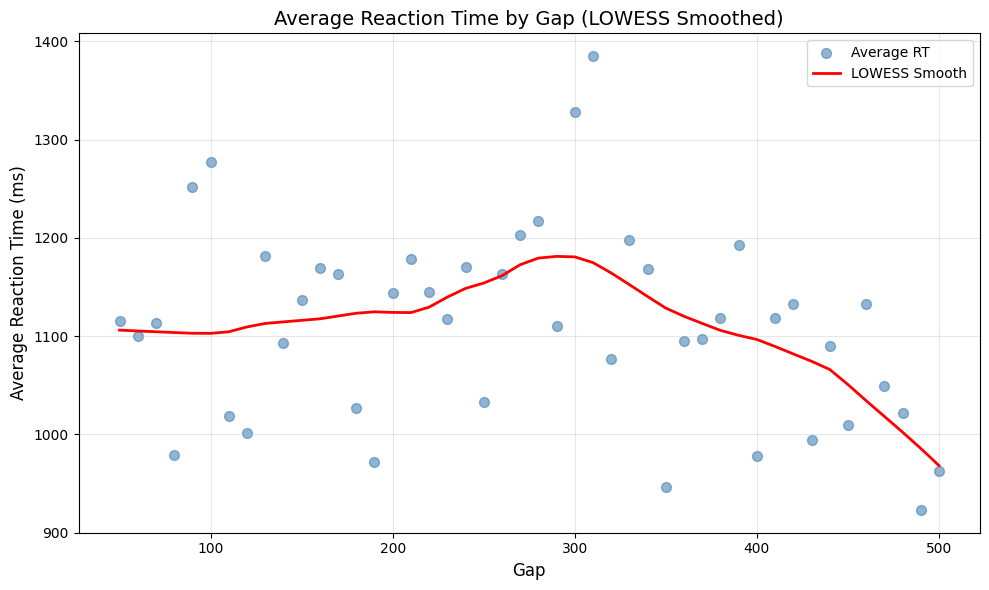

In [2]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np

# Specify your folder path here
folder_path = "/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/raw/manaswini"

# Get all CSV files in the folder
csv_files = list(Path(folder_path).glob("*.csv"))

# Read and combine all CSV files
all_data = []
for file in csv_files:
    df = pd.read_csv(file)
    all_data.append(df)

# Combine all dataframes
combined_df = pd.concat(all_data, ignore_index=True)

# Remove outliers using IQR method
Q1 = combined_df['RT'].quantile(0.25)
Q3 = combined_df['RT'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
combined_df = combined_df[(combined_df['RT'] >= lower_bound) & (combined_df['RT'] <= upper_bound)]
print(f"Removed outliers: RT < {lower_bound:.2f} or RT > {upper_bound:.2f}")
print(f"Remaining data points: {len(combined_df)}\n")

# Calculate average RT for each Gap
avg_rt_by_gap = combined_df.groupby('Gap')['RT'].mean().reset_index()
avg_rt_by_gap.columns = ['Gap', 'Average_RT']

# Sort by Gap for better readability
avg_rt_by_gap = avg_rt_by_gap.sort_values('Gap')

print("Average Reaction Time by Gap:")
print(avg_rt_by_gap)

# Create plot
plt.figure(figsize=(10, 6))

# Plot raw data
plt.scatter(avg_rt_by_gap['Gap'], avg_rt_by_gap['Average_RT'], 
            alpha=0.6, s=50, label='Average RT', color='steelblue')

# Apply LOWESS smoothing
from statsmodels.nonparametric.smoothers_lowess import lowess

# Calculate LOWESS smooth
smoothed = lowess(avg_rt_by_gap['Average_RT'], avg_rt_by_gap['Gap'], frac=0.3)

# Plot smoothed line
plt.plot(smoothed[:, 0], smoothed[:, 1], 
         color='red', linewidth=2, label='LOWESS Smooth')

plt.xlabel('Gap', fontsize=12)
plt.ylabel('Average Reaction Time (ms)', fontsize=12)
plt.title('Average Reaction Time by Gap (LOWESS Smoothed)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()